<a href="https://colab.research.google.com/github/kmkarakaya/Deep-Learning-Tutorials/blob/master/Agent_Design.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

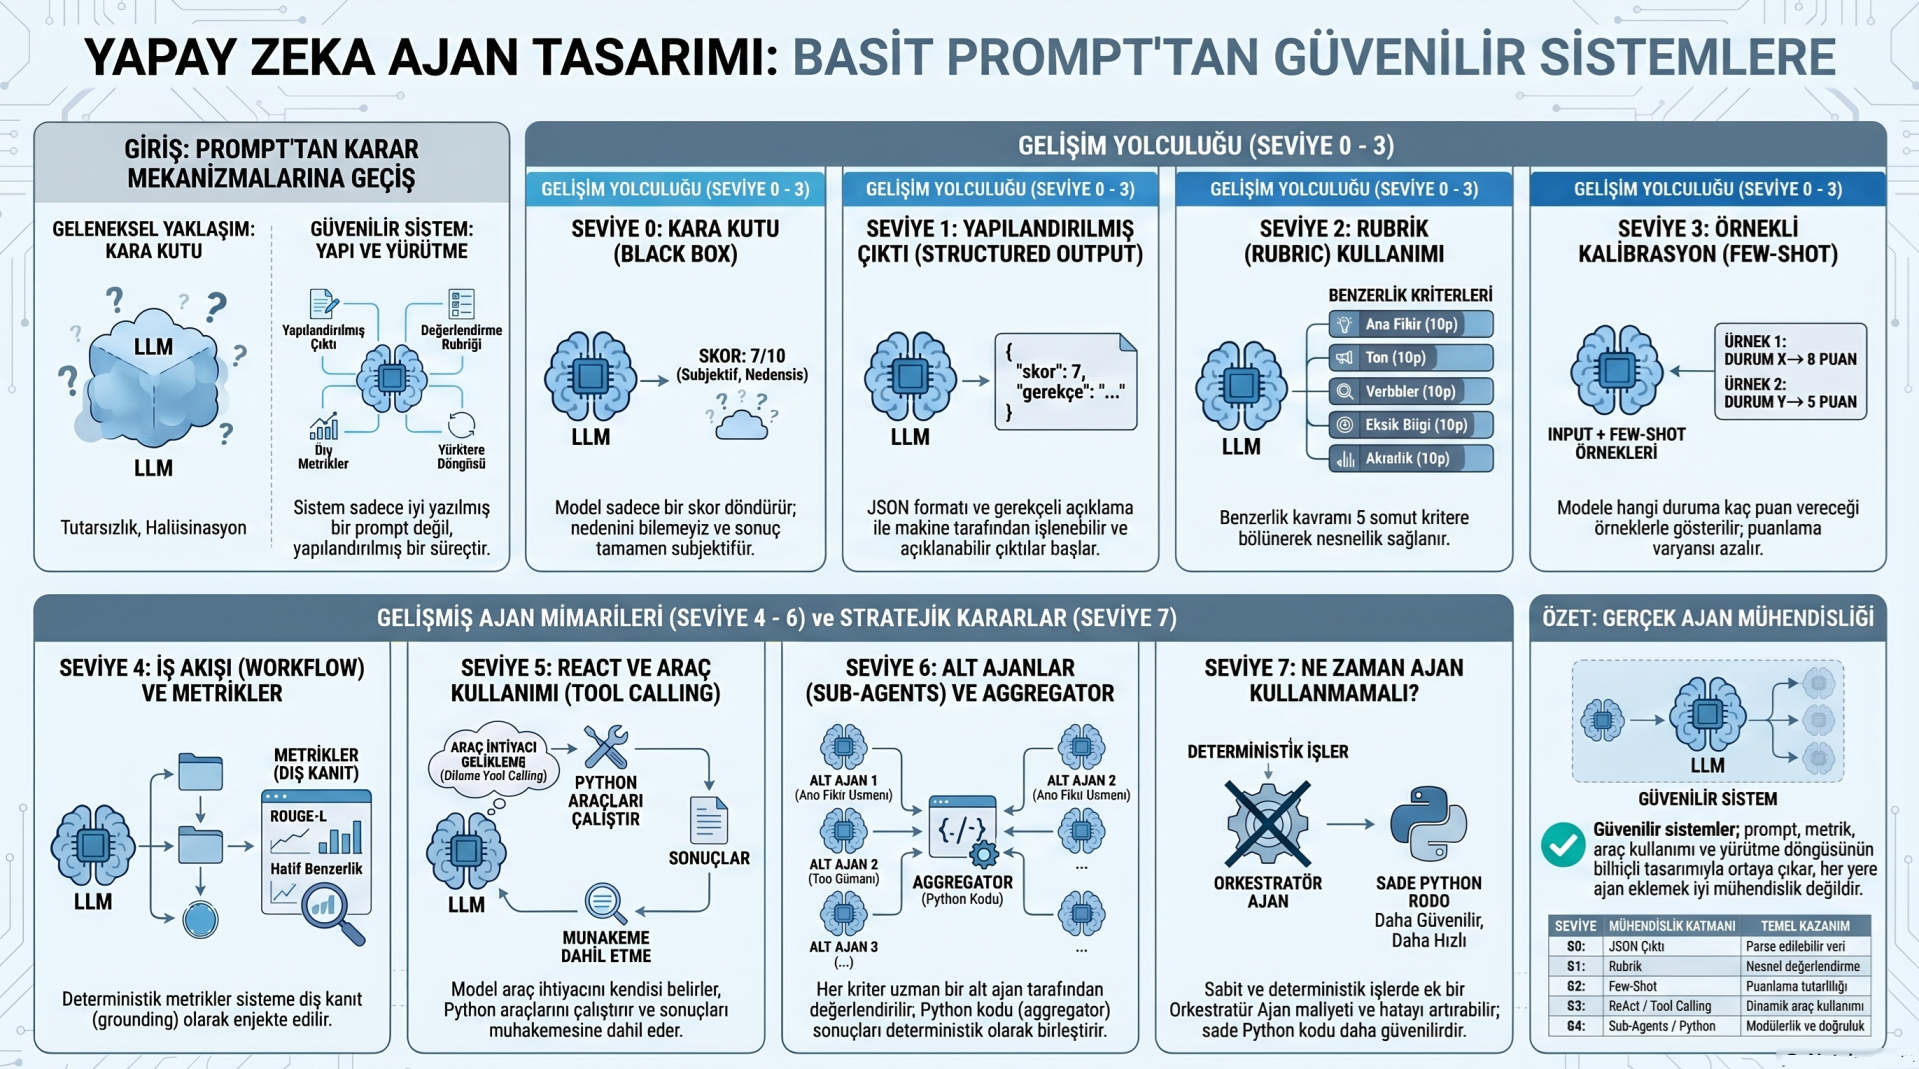

# Gerçek Yapay Zeka Ajanları (Artificial Intelligence Agents) Nasıl Tasarlanır?

## Kişilik Rolü (Persona) Promptlarından Araç Kullanan Karar Mekanizmalarına (Tool-Using Decision Mechanisms) Geçiş

Bu çalışmanın amacı, Büyük Dil Modeli (Large Language Model, LLM) tabanlı bir sistemi yalnızca iyi yazılmış bir prompt (istem) ile değil; yapılandırılmış çıktı, değerlendirme rubriği, dış metrikler, araç kullanımı ve gerçek yürütme döngüsü ile nasıl daha güvenilir hale getireceğimizi göstermektir.

### Motivasyon

Üretim ortamına (production) çıkacak bir sistemde sadece "Sen dünyanın en iyi yazılım mühendisisin..." gibi kişilik rolü (persona) promptları kullanmak yeterli değildir. Bu yaklaşım sistemi kara kutu (black box), tutarsız ve halüsinasyona (hallucination) açık hale getirebilir.

Yapay zeka ajanlarının (Artificial Intelligence Agents, AI Agents) asıl gücü onlara verilen rolden değil; **araç kullanımı (tool calling), temellendirme (grounding), açıklanabilirlik (explainability), iş akışı tasarımı (workflow design)** ve **yürütme döngüsünden (execution loop)** gelir.

### Eğitim Sonunda Öğrenecekleriniz

- Sistem promptu (system prompt) ile kullanıcı promptu (user prompt) ayrımını kurmayı.
- Yapılandırılmış çıktı (structured output) ile model cevabını makine tarafından işlenebilir hale getirmeyi.
- Değerlendirme Matrisi (rubric) kullanarak soyut değerlendirmeleri daha nesnel parçalara bölmeyi.
- Örnekli prompting (one-shot / few-shot prompting) ile Değerlendirme Matrisi puanlamasını kalibre etmeyi.
- ROUGE-L F1 ve hafif benzerlik skoru gibi deterministik metrikleri model yorumuna kanıt olarak eklemeyi.
- Araç kullanımı (tool calling) ile iş akışı (workflow) arasındaki farkı ayırt etmeyi.
- ReAct, yani akıl yürüt ve eyleme geç (Reason + Act), yaklaşımında prompt tasarımı ile gerçek Python yürütme döngüsü arasındaki farkı görmeyi.
- Her seviyenin süre, giriş tokenı (input token), çıkış tokenı (output token) ve toplam maliyet üzerindeki etkisini karşılaştırmayı.

Bu çalışma boyunca basit görünen bir problemi ele alacağız: **iki metnin benzerliğini ölçmek**. Önce acemi bir prompt ile başlayacağız; sonra yapılandırılmış çıktı, rubrik, örnekli kalibrasyon, metrikler, araç kullanımı ve ReAct döngüsüne doğru ilerleyeceğiz.


### Metin Benzerliği Deneyi

Bu eğtimde göreceğimiz deneyde, Metin 1 ve Metin 2 sabit kullanıcı promptu (user prompt) olarak Büyük Dil Modeline (Large Language Model, LLM) verilir. Sistem promptu (system prompt) olarak ise her Seviyede farklı bir yaklaşım kullanılırak iki metinin benzerliği bir skor olarak hesaplanmaya çalışılır.

Bu yapı eğitim boyunca korunacak: **kullanıcı girdisi sabit kalacak, yalnızca sistem promptu ve ajan mimarisi değişecektir.** Böylece seviyeler arasındaki farkı daha adil biçimde karşılaştırabiliriz.


## Colab ve Ollama Cloud Ayarı

Bu notebook varsayılan olarak **Ollama Cloud API** ile çalışacak şekilde ayarlanmıştır. Böylece Colab'da yerel Ollama servisi (`localhost:11434`) başlatmanız gerekmez.

Colab'da çalıştırmak için:

1. Ollama hesabınızdan bir API key oluşturun.
2. Colab sol menüsünden **Secrets** bölümüne girin.
3. `OLLAMA_API_KEY` adında bir secret ekleyin.
4. Notebook'u baştan çalıştırın.

Yerel bilgisayarda Ollama kullanmak isterseniz `OLLAMA_PROVIDER = "local"`, `OLLAMA_HOST = "http://localhost:11434"` ve `MODEL = "gemma4:latest"` olarak değiştirebilirsiniz.


In [48]:
import os
import sys
import json
import re
import time
import difflib
import html
import subprocess
from pathlib import Path
from getpass import getpass

# Ollama tool calling için güncel Python SDK kullanmak önemlidir.
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-U", "ollama"])

import ollama

from IPython.display import HTML, display

# @title Ollama Ayarları { display-mode: "form", form-width: "30%" }
# Bu form, Ollama bağlantı ayarlarını yapmanızı sağlar.
# Aşağıdaki seçenekleri değiştirerek farklı Ollama sağlayıcıları veya modelleri kullanabilirsiniz.

OLLAMA_PROVIDER_FORM = 'cloud' # @param ["cloud", "local"]
OLLAMA_HOST_FORM = 'https://ollama.com' # @param {type:"string"}
MODEL_FORM = 'gpt-oss:120b' # @param ["gpt-oss:120b", "gemma4:latest"]

# Formdan alınan değerleri global değişkenlere atayarak diğer hücrelerde de erişilebilir kılalım.
global OLLAMA_PROVIDER, OLLAMA_HOST, MODEL
OLLAMA_PROVIDER = OLLAMA_PROVIDER_FORM
OLLAMA_HOST = OLLAMA_HOST_FORM
MODEL = MODEL_FORM

THINK = False  # Adil metrik karşılaştırması için tüm seviyelerde aynı düşünme modu kullanılır.

PERFORMANCE_RESULTS = []
PERFORMANCE_BY_LEVEL = {}


def read_key_from_env_file(path):
    path = Path(path).expanduser()
    if not path.exists():
        return None

    pattern = re.compile(r'^\s*(?:export\s+)?OLLAMA_API_KEY\s*=\s*["\\]?([^"\'\n]+)["\\]?\s*$')
    for line in path.read_text(encoding="utf-8", errors="ignore").splitlines():
        match = pattern.match(line)
        if match:
            return match.group(1).strip()

    return None


def load_ollama_api_key(ask_if_missing=False):
    api_key = os.environ.get("OLLAMA_API_KEY")
    if api_key:
        return api_key

    try:
        from google.colab import userdata
        api_key = userdata.get("OLLAMA_API_KEY")
        if api_key:
            os.environ["OLLAMA_API_KEY"] = api_key
            return api_key
    except Exception:
        pass

    # Jupyter/VS Code kernel'leri sonradan güncellenen ~/.zshrc ortamını otomatik görmeyebilir.
    # Bu yüzden Mac'te sık kullanılan shell dosyalarını doğrudan okuyoruz.
    for candidate_path in [".env", "~/.zshrc", "~/.zprofile", "~/.bash_profile", "~/.bashrc"]:
        api_key = read_key_from_env_file(candidate_path)
        if api_key:
            os.environ["OLLAMA_API_KEY"] = api_key
            return api_key

    if ask_if_missing:
        api_key = getpass("Ollama API key girin: ").strip()
        if api_key:
            os.environ["OLLAMA_API_KEY"] = api_key
            return api_key

    return None


def create_ollama_client(host=OLLAMA_HOST, provider=OLLAMA_PROVIDER):
    if provider == "cloud":
        api_key = load_ollama_api_key(ask_if_missing=True)
        if not api_key:
            raise RuntimeError(
                "Ollama Cloud için OLLAMA_API_KEY gerekli. "
                "Colab Secrets bölümüne OLLAMA_API_KEY ekleyin, ~/.zshrc içine export edin "
                "veya os.environ['OLLAMA_API_KEY'] ile ayarlayın."
            )
        return ollama.Client(
            host=host,
            headers={"Authorization": "Bearer " + api_key},
        )

    return ollama.Client(host=host)

# Ollama istemcisini yeni ayarlarla oluşturalım
ollama_client = create_ollama_client(host=OLLAMA_HOST, provider=OLLAMA_PROVIDER)

print(f"Ollama istemcisi başarıyla hazırlandı.")
print(f"Sağlayıcı (OLLAMA_PROVIDER): {OLLAMA_PROVIDER}")
print(f"Host (OLLAMA_HOST): {OLLAMA_HOST}")
print(f"Model (MODEL): {MODEL}")

Ollama istemcisi başarıyla hazırlandı.
Sağlayıcı (OLLAMA_PROVIDER): cloud
Host (OLLAMA_HOST): https://ollama.com
Model (MODEL): gpt-oss:120b


In [49]:
# @title Girdiyi Hazırla { display-mode: "form" }
METIN_1 = """Yapay zeka modellerinin eğitilmesi sürecinde, yüksek kaliteli veri setlerinin kullanılması kritik bir öneme sahiptir. Eğer veri seti hatalı, yanlı veya eksik bilgiler içeriyorsa, modelin üreteceği sonuçlar da kaçınılmaz olarak kusurlu ve güvenilmez olacaktır. Bu nedenle veri temizliği, model mimarisinin karmaşıklığından bile daha öncelikli bir adımdır.""" # @param {type:"string"}

METIN_2 = """Makine öğrenmesi algoritmalarının başarısı, büyük ölçüde beslendikleri bilginin kalitesine bağlıdır. Kirli, önyargılı ya da noksan verilerle beslenen algoritmalar, doğal olarak yanlış ve itimat edilemez çıktılar verecektir. Dolayısıyla, verilerin filtrelenmesi ve düzenlenmesi, sistemin altyapısını kurmaktan çok daha elzem bir süreçtir.""" # @param {type:"string"}

### Yardımcı Fonksiyonlar:

In [50]:
# @title
def build_user_prompt(extra_context=None):
    user_prompt = f"""Metin 1:
{METIN_1}

Metin 2:
{METIN_2}"""

    if extra_context:
        user_prompt = f"{user_prompt}\n\n{extra_context}"

    return user_prompt


def seconds_from_nanoseconds(value):
    if value is None:
        return None
    return value / 1_000_000_000


def record_performance(level_name, metrics):
    if not level_name:
        return

    record = {"level": level_name, **metrics}
    PERFORMANCE_BY_LEVEL[level_name] = record

    for index, existing_record in enumerate(PERFORMANCE_RESULTS):
        if existing_record["level"] == level_name:
            PERFORMANCE_RESULTS[index] = record
            break
    else:
        PERFORMANCE_RESULTS.append(record)


def run_similarity_experiment(system_prompt, model=MODEL, host=OLLAMA_HOST, provider=OLLAMA_PROVIDER, extra_user_context=None, level_name=None, think=THINK):
    client = create_ollama_client(host=host, provider=provider)
    user_prompt = build_user_prompt(extra_context=extra_user_context)
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt},
    ]

    started_at = time.perf_counter()
    response = client.chat(model=model, messages=messages, think=think)
    elapsed_seconds = time.perf_counter() - started_at

    input_tokens = response.get("prompt_eval_count")
    output_tokens = response.get("eval_count")
    total_tokens = None
    if input_tokens is not None and output_tokens is not None:
        total_tokens = input_tokens + output_tokens

    metrics = {
        "model": model,
        "think": think,
        "provider": provider,
        "host": host,
        "elapsed_seconds": elapsed_seconds,
        "ollama_total_duration_seconds": seconds_from_nanoseconds(response.get("total_duration")),
        "input_tokens": input_tokens,
        "output_tokens": output_tokens,
        "total_tokens": total_tokens,
        "system_prompt_chars": len(system_prompt),
        "user_prompt_chars": len(user_prompt),
        "extra_context_chars": len(extra_user_context or ""),
        "response_chars": len(response["message"]["content"]),
    }
    record_performance(level_name, metrics)

    return {
        "content": response["message"]["content"],
        "metrics": metrics,
    }


def get_response_content(result):
    if isinstance(result, dict) and "content" in result:
        return result["content"]
    return result


def parse_json_response(response_text):
    response_text = get_response_content(response_text)
    cleaned = response_text.strip()
    code_block_match = re.search(r"```(?:json)?\s*(.*?)\s*```", cleaned, re.DOTALL)
    if code_block_match:
        cleaned = code_block_match.group(1).strip()

    return json.loads(cleaned)


def print_json_response(response_text):
    parsed_response = parse_json_response(response_text)
    print(json.dumps(parsed_response, ensure_ascii=False, indent=2))


def print_usage_report(result):
    metrics = result["metrics"]
    print("\n--- Çalışma Maliyeti ---")
    print(f"Model: {metrics['model']}")
    print(f"Düşünme modu (think): {metrics.get('think')}")
    print(f"Sağlayıcı (provider): {metrics.get('provider')}")
    print(f"Host: {metrics.get('host')}")
    print(f"Response süresi: {metrics['elapsed_seconds']:.2f} sn")
    if metrics["ollama_total_duration_seconds"] is not None:
        print(f"Ollama toplam süre: {metrics['ollama_total_duration_seconds']:.2f} sn")
    print(f"Giriş tokenı (input token): {metrics['input_tokens']}")
    print(f"Çıkış tokenı (output token): {metrics['output_tokens']}")
    print(f"Toplam token: {metrics['total_tokens']}")
    if "token_metric_steps" in metrics:
        print(f"Token metriği alınan adım sayısı: {metrics['token_metric_steps']}")
        print(f"Token metriği eksik adım sayısı: {metrics['missing_token_metric_steps']}")
    if "required_tool_count" in metrics:
        print(f"Gerekli tool sayısı: {metrics['required_tool_count']}")
        print(f"Tamamlanan gerekli tool sayısı: {metrics['completed_required_tool_count']}")
    if "sub_agent_count" in metrics:
        print(f"Sub-agent sayısı: {metrics['sub_agent_count']}")
        print(f"Aggregator tipi: {metrics['aggregator_type']}")
        print(f"Toplam LLM çağrısı: {metrics['total_llm_call_count']}")
    if metrics.get("token_accounting_note"):
        print(f"Not: {metrics['token_accounting_note']}")
    print(f"Sistem promptu karakteri (system prompt chars): {metrics['system_prompt_chars']}")
    print(f"Kullanıcı promptu karakteri (user prompt chars): {metrics['user_prompt_chars']}")
    print(f"Yanıt karakteri (response chars): {metrics['response_chars']}")


## Metrik Araçları

Seviye 4'ten itibaren Büyük Dil Modeline (Large Language Model, LLM) dış sistemler tarafından hesaplanmış metrikleri vereceğiz. Bu notebook'ta hızlı ve bağımlılıksız çalışması için iki hafif metrik kullanıyoruz:

- **ROUGE-L F1:** En uzun ortak alt diziye (longest common subsequence) dayalı kelime/dizi örtüşmesi metriği.
- **Hafif benzerlik skoru (lightweight similarity score):** Token cosine, token Jaccard, karakter 3-gram cosine ve sequence ratio skorlarının ağırlıklı birleşimi.

Bu metrikler gerçek bir semantik gömme (semantic embedding) modeli kadar güçlü değildir; fakat eğitim amacı için hızlı, şeffaf ve deterministiktir.


In [51]:
# @title
def tokenize_for_metric(text):
    return re.findall(r"\w+", text.lower(), flags=re.UNICODE)


def ngrams(tokens, n):
    return [tuple(tokens[index:index + n]) for index in range(len(tokens) - n + 1)]


def precision_recall_f1(overlap_count, reference_count, candidate_count):
    precision = overlap_count / candidate_count if candidate_count else 0.0
    recall = overlap_count / reference_count if reference_count else 0.0
    f1 = (2 * precision * recall / (precision + recall)) if precision + recall else 0.0
    return {"precision": precision, "recall": recall, "f1": f1}


def rouge_n(reference_text, candidate_text, n=1):
    reference_ngrams = ngrams(tokenize_for_metric(reference_text), n)
    candidate_ngrams = ngrams(tokenize_for_metric(candidate_text), n)

    reference_counts = {}
    for item in reference_ngrams:
        reference_counts[item] = reference_counts.get(item, 0) + 1

    candidate_counts = {}
    for item in candidate_ngrams:
        candidate_counts[item] = candidate_counts.get(item, 0) + 1

    overlap_count = sum(
        min(reference_counts.get(item, 0), candidate_counts.get(item, 0))
        for item in candidate_counts
    )

    return precision_recall_f1(
        overlap_count=overlap_count,
        reference_count=len(reference_ngrams),
        candidate_count=len(candidate_ngrams),
    )


def longest_common_subsequence_length(reference_tokens, candidate_tokens):
    previous_row = [0] * (len(candidate_tokens) + 1)
    for reference_token in reference_tokens:
        current_row = [0]
        for index, candidate_token in enumerate(candidate_tokens, start=1):
            if reference_token == candidate_token:
                current_row.append(previous_row[index - 1] + 1)
            else:
                current_row.append(max(previous_row[index], current_row[-1]))
        previous_row = current_row
    return previous_row[-1]


def rouge_l(reference_text, candidate_text):
    reference_tokens = tokenize_for_metric(reference_text)
    candidate_tokens = tokenize_for_metric(candidate_text)
    lcs_length = longest_common_subsequence_length(reference_tokens, candidate_tokens)
    return precision_recall_f1(
        overlap_count=lcs_length,
        reference_count=len(reference_tokens),
        candidate_count=len(candidate_tokens),
    )


def calculate_rouge(reference_text, candidate_text):
    return {
        "rouge_1": rouge_n(reference_text, candidate_text, n=1),
        "rouge_2": rouge_n(reference_text, candidate_text, n=2),
        "rouge_l": rouge_l(reference_text, candidate_text),
    }


def count_items(items):
    counts = {}
    for item in items:
        counts[item] = counts.get(item, 0) + 1
    return counts


def cosine_similarity_from_counts(first_counts, second_counts):
    shared_items = set(first_counts) & set(second_counts)
    dot_product = sum(first_counts[item] * second_counts[item] for item in shared_items)
    first_norm = sum(value * value for value in first_counts.values()) ** 0.5
    second_norm = sum(value * value for value in second_counts.values()) ** 0.5
    if not first_norm or not second_norm:
        return 0.0
    return dot_product / (first_norm * second_norm)


def token_cosine_similarity(reference_text, candidate_text):
    return cosine_similarity_from_counts(
        count_items(tokenize_for_metric(reference_text)),
        count_items(tokenize_for_metric(candidate_text)),
    )


def token_jaccard_similarity(reference_text, candidate_text):
    reference_tokens = set(tokenize_for_metric(reference_text))
    candidate_tokens = set(tokenize_for_metric(candidate_text))
    union = reference_tokens | candidate_tokens
    if not union:
        return 0.0
    return len(reference_tokens & candidate_tokens) / len(union)


def character_ngrams(text, n=3):
    normalized_text = re.sub(r"\s+", " ", text.lower()).strip()
    if len(normalized_text) < n:
        return [normalized_text] if normalized_text else []
    return [normalized_text[index:index + n] for index in range(len(normalized_text) - n + 1)]


def character_ngram_cosine_similarity(reference_text, candidate_text, n=3):
    return cosine_similarity_from_counts(
        count_items(character_ngrams(reference_text, n=n)),
        count_items(character_ngrams(candidate_text, n=n)),
    )


def sequence_similarity(reference_text, candidate_text):
    return difflib.SequenceMatcher(None, reference_text.lower(), candidate_text.lower()).ratio()


def calculate_lightweight_similarity(reference_text, candidate_text):
    token_cosine = token_cosine_similarity(reference_text, candidate_text)
    token_jaccard = token_jaccard_similarity(reference_text, candidate_text)
    char_3gram_cosine = character_ngram_cosine_similarity(reference_text, candidate_text, n=3)
    sequence_ratio = sequence_similarity(reference_text, candidate_text)
    combined_score = (
        0.35 * token_cosine
        + 0.15 * token_jaccard
        + 0.35 * char_3gram_cosine
        + 0.15 * sequence_ratio
    )
    return {
        "token_cosine": token_cosine,
        "token_jaccard": token_jaccard,
        "char_3gram_cosine": char_3gram_cosine,
        "sequence_ratio": sequence_ratio,
        "combined_score": combined_score,
    }
def print_metric_report(reference_text=METIN_1, candidate_text=METIN_2):
    rouge_scores = calculate_rouge(reference_text, candidate_text)
    print("ROUGE skorları:")
    print(json.dumps(rouge_scores, ensure_ascii=False, indent=2))

    lightweight_scores = calculate_lightweight_similarity(reference_text, candidate_text)
    print("\nHafif benzerlik skorları:")
    print(json.dumps(lightweight_scores, ensure_ascii=False, indent=2))


def build_level_4_metrics_context(reference_text=METIN_1, candidate_text=METIN_2):
    rouge_scores = calculate_rouge(reference_text, candidate_text)
    lightweight_scores = calculate_lightweight_similarity(reference_text, candidate_text)
    return (
        "Sistem Metrikleri -> "
        f"ROUGE-L F1: {rouge_scores['rouge_l']['f1']:.3f}, "
        f"Hafif Benzerlik Skoru: {lightweight_scores['combined_score']:.3f} "
        "(token cosine + token Jaccard + karakter 3-gram cosine + sequence ratio birleşimi)"
    )

In [52]:
print_metric_report()

ROUGE skorları:
{
  "rouge_1": {
    "precision": 0.1282051282051282,
    "recall": 0.1111111111111111,
    "f1": 0.11904761904761904
  },
  "rouge_2": {
    "precision": 0.0,
    "recall": 0.0,
    "f1": 0.0
  },
  "rouge_l": {
    "precision": 0.1282051282051282,
    "recall": 0.1111111111111111,
    "f1": 0.11904761904761904
  }
}

Hafif benzerlik skorları:
{
  "token_cosine": 0.15016481204905044,
  "token_jaccard": 0.06666666666666667,
  "char_3gram_cosine": 0.4035776656990742,
  "sequence_ratio": 0.02604920405209841,
  "combined_score": 0.20771724781965836
}


### **Seviye 0 - Acemi Yaklaşım: Kara Kutu (Black Box) ve Halüsinasyon (Hallucination)**

**Senaryo:** Uygulamamızda üretilen Metin 1 ile Metin 2'nin ne kadar benzer olduğunu 0-100 arasında bulmamız gerekiyor. Örneğin bir geri getirmeli üretim (Retrieval-Augmented Generation, RAG) sisteminde, üretilen cevabın referans metne ne kadar sadık olduğunu ölçmek isteyebiliriz.

**Acemi prompt (naive prompt):**

"Sen bir metin analistisin. Sana verilen Metin 1 ve Metin 2'yi karşılaştırıp ne kadar benzer olduklarına karar ver. Benzerliği 0-100 arasında bir sayısal değer ile döndür. 0: Hiç benzemiyorlar, 100: Tamamen kelime kelime aynılar."

**Neden sorunlu?**

1. **Kara kutu (Black Box):** Model yalnızca bir sayı döndürürse bu sayının neden verildiğini bilemeyiz.
2. **Subjektiflik (Subjectivity):** Aynı prompt farklı çalıştırmalarda farklı skorlar üretebilir.
3. **Halüsinasyon riski (Hallucination Risk):** Büyük Dil Modelleri (Large Language Models, LLMs) doğal olarak matematiksel ölçüm motorları değildir; olası bir sonraki tokenı tahmin ederler.

Bu seviye bilinçli olarak zayıf bırakılmıştır. Amacımız, sonraki seviyelerde hangi mühendislik katmanlarının bu zayıflıkları azalttığını görmektir.


In [53]:
SEVIYE_0_SYSTEM_PROMPT = """Sen bir metin analistisin.
Sana verilen Metin 1 ve Metin 2'yi karşılaştırıp ne kadar benzer olduklarına karar ver.
Benzerliği 0-100 arasında bir sayısal değer ile döndür.
0: Hiç benzemiyorlar, 100: Tamamen kelime kelime aynılar."""

In [54]:
level_0_result = run_similarity_experiment(SEVIYE_0_SYSTEM_PROMPT, level_name="Seviye 0")
level_0_response = get_response_content(level_0_result)

print(level_0_response)
print_usage_report(level_0_result)

Benzerlik puanı: **72**

--- Çalışma Maliyeti ---
Model: gpt-oss:120b
Düşünme modu (think): False
Sağlayıcı (provider): cloud
Host: https://ollama.com
Response süresi: 1.75 sn
Ollama toplam süre: 1.59 sn
Giriş tokenı (input token): 335
Çıkış tokenı (output token): 131
Toplam token: 466
Sistem promptu karakteri (system prompt chars): 228
Kullanıcı promptu karakteri (user prompt chars): 711
Yanıt karakteri (response chars): 23


### **Seviye 1 - Yapılandırılmış Çıktı (Structured Output) ve Açıklanabilirlik (Explainability)**

**Gelişim:** Bu seviyede modelden yalnızca skor değil, makine tarafından işlenebilir bir JSON (JavaScript Object Notation) çıktısı ve kısa gerekçeli açıklama (rationale) istiyoruz.

Buradaki amaç modelin gizli iç düşüncelerini birebir almak değildir. Amaç, verdiği skoru hangi gözlemlere dayandırdığını özetleyen denetlenebilir bir açıklama üretmesini sağlamaktır.

**Seviye 1 sistem promptu (system prompt) ve mimari:**

Modelden şu alanları içeren katı bir JSON çıktısı istenir:

- `reasoning`: Benzerlik ve farklılıkların kısa gerekçesi.
- `similarity_score`: 0-100 arası nihai benzerlik skoru.

**Neden daha iyi?**

- **Açıklanabilirlik (Explainability):** Skorun arkasındaki gerekçeyi görebiliriz.
- **Hata ayıklama (Debugging):** Yanlış skor geldiğinde modelin hangi detayı kaçırdığını inceleyebiliriz.
- **Entegrasyon kolaylığı (Integration):** JSON çıktısı uygulama kodu tarafından parse edilebilir.

**Eksik kalan ne?**

Skor hâlâ subjektiftir. 0-100 arası skalanın nasıl kullanılacağı modele bırakılmıştır. Bu yüzden bir sonraki seviyede soyut benzerlik kavramını rubriklere böleceğiz.


In [55]:
SEVIYE_1_SYSTEM_PROMPT = """Sen bir metin analistisin. Amacın iki metnin anlamsal benzerliğini ölçmektir.

Çıktını KESİNLİKLE geçerli bir JSON object olarak vermelisin. Markdown veya ek metin kullanma.

Zorunlu JSON alanları:
- reasoning: Bu iki metne özel benzerlik ve farklılık gerekçesi.
- similarity_score: 0-100 arası bir tam sayı.

Beklenen JSON şeması aşağıdaki gibidir. Bu şemayı cevap olarak yazma; yalnızca çıktı kontratı olarak kullan:
{
  "type": "object",
  "required": ["reasoning", "similarity_score"],
  "properties": {
    "reasoning": {"type": "string"},
    "similarity_score": {"type": "integer", "minimum": 0, "maximum": 100}
  }
}"""

In [56]:
level_1_result = run_similarity_experiment(SEVIYE_1_SYSTEM_PROMPT, level_name="Seviye 1")
level_1_response = get_response_content(level_1_result)

print_json_response(level_1_result)
print_usage_report(level_1_result)

{
  "reasoning": "İki metin de yapay zeka/makine öğrenmesi sistemlerinin başarısının veri kalitesine bağlı olduğunu vurguluyor, hatalı, yanlı veya eksik verilerin hatalı ve güvenilmez çıktılar üreteceği sonucuna aynı şekilde ulaşmaktadır. Her iki metin de veri temizliği/filtreleme ve düzenlemenin, model mimarisi ya da sistem altyapısı gibi teknik unsurlardan daha öncelikli ve kritik bir adım olduğunu savunur. Farklılıkları ise terminoloji (Yapay zeka modelleri vs. makine öğrenmesi algoritmaları), kullanılan ifadeler (veri temizliği vs. verilerin filtrelenmesi, model mimarisi vs. sistem altyapısı) ve anlatım tarzıdır. Anlamsal içerik ve çıkarımlar neredeyse aynı olduğundan, yüksek bir benzerlik puanı verilebilir.",
  "similarity_score": 92
}

--- Çalışma Maliyeti ---
Model: gpt-oss:120b
Düşünme modu (think): False
Sağlayıcı (provider): cloud
Host: https://ollama.com
Response süresi: 3.93 sn
Ollama toplam süre: 3.77 sn
Giriş tokenı (input token): 450
Çıkış tokenı (output token): 412
Topl

### **Seviye 2 - Değerlendirme Matrisi (Rubric) ve Nesnellik (Objectivity)**

**Gelişim:** Ajanın (agent) "benzerlik" gibi soyut bir kavramı tek başına yorumlamasına izin vermiyoruz. Bunun yerine değerlendirmeyi beş ayrı kritere bölüyoruz. Bu yaklaşım böl ve yönet (divide and conquer) prensibinin prompt tasarımındaki karşılığıdır.

**Seviye 2 sistem promptu (system prompt) ve mimari:**

Model iki metni aşağıdaki ***Değerlendirme Matrisi (rubric)*** üzerinden değerlendirir:

1. **Ana fikir:** İki metin aynı ana mesajı mı veriyor?
2. **Ton ve üslup:** Metinlerin resmiyeti ve duygusu benzer mi?
3. **Varlıklar (entities):** İsimler, tarihler, sayılar ve önemli nesneler uyumlu mu?
4. **Eksik bilgi:** Metin 2, Metin 1'deki önemli bir detayı atlıyor mu?
5. **Akıcılık:** Metin 2 yapısal olarak tutarlı ve okunabilir mi?

**Neden daha iyi?**

- **Temellendirme (Grounding):** Model soyut bir genel skor yerine somut kriterlere cevap verir.
- **Nesnellik (Objectivity):** Her kriter 0-20 arasında puanlandığı için toplam skor daha tutarlı hale gelir.
- **Karşılaştırılabilirlik (Comparability):** Farklı sistem promptlarını aynı rubrik üzerinden değerlendirebiliriz.

**Eksik kalan ne?**

Bu seviye hâlâ tamamen Büyük Dil Modeli (Large Language Model, LLM) yorumuna dayanır. Dışarıdan hesaplanmış deterministik bir kanıt yoktur. Bir sonraki seviyede modele metrik sonuçları vereceğiz.


In [57]:
SEVIYE_2_SYSTEM_PROMPT = """Sen uzman bir değerlendiricisin. İki metni aşağıdaki 5 kritere göre değerlendir. Her kriter 0-20 puan arasındadır.

Rubrik:

1. Ana Fikir (0-20): İki metin aynı ana mesajı mı veriyor?
2. Ton ve Üslup (0-20): İki metnin resmiyeti ve duygusu aynı mı?
3. Varlıklar (Entities) (0-20): Metinlerde geçen isimler, tarihler, sayılar eşleşiyor mu?
4. Eksik Bilgi (0-20): Metin 2, Metin 1'deki önemli bir detayı atlamış mı?
5. Akıcılık (0-20): Metin 2 yapısal olarak ne kadar tutarlı?

Çıktını KESİNLİKLE geçerli bir JSON object olarak üret. Markdown veya ek metin kullanma.

Zorunlu JSON alanları:
- evaluations: 5 öğeli liste. Sırasıyla Ana Fikir, Ton ve Üslup, Varlıklar, Eksik Bilgi ve Akıcılık kriterlerini içermeli.
- Her evaluations öğesi criterion, score ve explanation alanlarını içermeli.
- score: 0-20 arasında tam sayı olmalı.
- explanation: Bu iki metne özel, kısa ve somut gerekçe olmalı. Boş, şablon veya örnek açıklama kullanma.
- total_score: Beş kriter skorunun toplamı olmalı.

Beklenen JSON şeması aşağıdaki gibidir. Bu şemayı cevap olarak yazma; yalnızca çıktı kontratı olarak kullan:
{
  "type": "object",
  "required": ["evaluations", "total_score"],
  "properties": {
    "evaluations": {
      "type": "array",
      "minItems": 5,
      "maxItems": 5,
      "items": {
        "type": "object",
        "required": ["criterion", "score", "explanation"],
        "properties": {
          "criterion": {"type": "string", "enum": ["Ana Fikir", "Ton ve Üslup", "Varlıklar", "Eksik Bilgi", "Akıcılık"]},
          "score": {"type": "integer", "minimum": 0, "maximum": 20},
          "explanation": {"type": "string"}
        }
      }
    },
    "total_score": {"type": "integer", "minimum": 0, "maximum": 100}
  }
}"""

In [58]:
level_2_result = run_similarity_experiment(SEVIYE_2_SYSTEM_PROMPT, level_name="Seviye 2")
level_2_response = get_response_content(level_2_result)

print_json_response(level_2_result)
print_usage_report(level_2_result)

{
  "evaluations": [
    {
      "criterion": "Ana Fikir",
      "score": 18,
      "explanation": "Her iki metin de düşük kaliteli veriyle eğitilen modellerin hatalı sonuçlar üreteceğini ve veri temizliğinin öncelikli olduğunu vurguluyor, bu yüzden ana mesaj tamamen örtüşüyor."
    },
    {
      "criterion": "Ton ve Üslup",
      "score": 18,
      "explanation": "Metinler her ikisi de akademik ve resmi bir dil kullanıyor; kelime seçimleri farklı olsa da duygu ve ciddiyet düzeyi eşdeğerdir."
    },
    {
      "criterion": "Varlıklar",
      "score": 20,
      "explanation": "İsim, tarih, sayı gibi özel varlıklar içermese de her iki metinde geçen \"veri seti\", \"model/algoritma\", \"temizlik/filtreleme\" gibi kavramlar tamamen eşleşiyor."
    },
    {
      "criterion": "Eksik Bilgi",
      "score": 19,
      "explanation": "Metin 2, Metin 1'deki \"model mimarisi\" ifadesini \"sistemin altyapısı\" olarak yeniden çerçevelese de, veri temizliğinin önceliği gibi önemli bir detayı atlam

### **Seviye 3 - Örnekli Değerlendirme Matrisi Kalibrasyonu (One-Shot / Few-Shot Prompting)**

**Gelişim:** Seviye 2'de modele Değerlendirme Matrisi verdik; fakat bu hâlâ sıfır-örnekli prompting (zero-shot prompting) idi. Model kriterleri okudu ama puanlama davranışını örneklerden kalibre etmedi.

Bu seviyede her Değerlendirme Matrisi kriteri için kısa örnekler ekliyoruz. Bu yaklaşım örnekli prompting (one-shot / few-shot prompting) olarak adlandırılır:

- **Tek örnekli prompting (one-shot prompting):** Modele görev için bir örnek gösterilir.
- **Az örnekli prompting (few-shot prompting):** Modele görevin farklı durumlarını temsil eden birkaç örnek gösterilir.

Buradaki amaç modele cevabı ezberletmek değildir. Amaç, “20 puan ne zaman verilir?”, “10 puan hangi durumda uygundur?”, “0 puan hangi durumda verilir?” gibi karar sınırlarını kalibre etmektir.

**Neden Seviye 2'den daha iyi?**

- **Puanlama kalibrasyonu (scoring calibration):** Rubrik puanlarının anlamı örneklerle somutlaşır.
- **Varyans azaltma (variance reduction):** Aynı prompt farklı çalıştırmalarda daha tutarlı skorlar üretir.
- **Kriter davranışı öğretimi:** Model yalnızca kriter adlarını değil, kriterlerin nasıl uygulanacağını da görür.

**Dikkat edilmesi gereken nokta:** Few-shot örnekleri çok uzun olursa giriş tokenı (input token) artar. Bu yüzden örnekler kısa, temsil gücü yüksek ve doğrudan rubrik kararını açıklayan biçimde seçilmelidir.

**Deney hijyeni notu:** Bu seviyede tanımlanan rubrik ve kalibrasyon metni `ORTAK_RUBRIK_VE_KALIBRASYON_PROMPT` içinde tutulur. Seviye 4 aynı metni kullanır; böylece iki seviye arasındaki fark rubrik değişikliği değil, yalnızca dış metrik bağlamıdır.


In [59]:
ORTAK_RUBRIK_VE_KALIBRASYON_PROMPT = """Değerlendirme Matrisi (Rubric):

1. Ana Fikir (0-20): İki metin aynı ana mesajı mı veriyor?
2. Ton ve Üslup (0-20): İki metnin resmiyeti, teknikliği ve anlatım tonu benzer mi?
3. Varlıklar / Entities (0-20): Metinlerde geçen temel kavramlar, teknik terimler, kişi/kurum/tarih/sayı gibi varlıklar korunmuş mu?
4. Eksik Bilgi (0-20): Metin 2, Metin 1'deki önemli bir detayı, ana iddiayı veya kritik sonucu atlamış mı?
5. Akıcılık (0-20): Metin 2 yapısal olarak tutarlı, okunabilir ve mantıksal olarak iyi akıyor mu?

Puanlama kalibrasyonu:

* Her kriter 0 ile 20 arasında puanlanır.
* Puanlar yalnızca 0, 10 ve 20 ile sınırlı değildir; değerlendirici 1, 2, 3 ... 19 gibi ara puanlar da verebilir.
* 20 puan: Kriter neredeyse tamamen karşılanır.
* 15-19 puan: Kriter büyük ölçüde karşılanır; yalnızca küçük farklar veya ihmal edilebilir eksikler vardır.
* 10-14 puan: Kriter kısmen karşılanır; ana bağlantı korunur ancak belirgin fark, eksik veya zayıflık vardır.
* 5-9 puan: Kriter sınırlı düzeyde karşılanır; benzerlik zayıftır veya önemli unsurlar eksiktir.
* 0-4 puan: Kriter hiç karşılanmaz ya da metinler bu kriter açısından büyük ölçüde alakasızdır.

Not: Aşağıdaki 0, 10 ve 20 puan örnekleri yalnızca kalibrasyon çıpalarıdır.
Değerlendirici, iki metin arasındaki benzerlik düzeyine göre bu çıpaların arasında uygun ara puanı seçmelidir.

Kriter bazlı kalibrasyon örnekleri:

Ana Fikir:

* 20 puan örneği: "Toplu taşıma yatırımları şehir içi trafik yoğunluğunu azaltır" ve "Kent trafiğini hafifletmenin etkili yollarından biri toplu ulaşımı güçlendirmektir" aynı ana fikri verir.
* 10 puan örneği: İki metin de şehir içi ulaşımdan söz eder ama biri trafik sıkışıklığına, diğeri karbon emisyonlarının azaltılmasına odaklanır.
* 0 puan örneği: Biri metro seferlerinin artırılmasını, diğeri bir futbol maçının sonucunu anlatır.

Ton ve Üslup:

* 20 puan örneği: İki metin de belediye raporu üslubunda, resmi ve bilgilendirici bir dille yazılmıştır.
* 10 puan örneği: Biri resmi bir ulaşım planı diliyle, diğeri daha gündelik ve vatandaş odaklı bir dille yazılmıştır ama temel anlam korunmuştur.
* 0 puan örneği: Biri teknik ulaşım raporu, diğeri alaycı veya reklam diliyle yazılmıştır.

Varlıklar / Entities:

* 20 puan örneği: Aynı metro hattı, belediye adı, tarih, sefer sıklığı, durak sayısı ve yolcu kapasitesi korunmuştur.
* 10 puan örneği: Ana varlıklar korunur ama bazı ikincil bilgiler, örneğin durak adları veya sefer aralıkları genelleştirilir.
* 0 puan örneği: Metinlerde geçen temel kurum, hat adı, tarih, sayı veya ulaşım türü farklıdır.

Eksik Bilgi:

* 20 puan örneği: Metin 2, Metin 1'deki tüm kritik bilgileri; yeni hattın güzergâhını, açılış tarihini, sefer sıklığını ve beklenen yolcu kapasitesini taşır.
* 10 puan örneği: Ana mesaj korunur ama hattın hangi ilçelerden geçeceği veya ne zaman hizmete gireceği gibi önemli bir destekleyici detay eksiktir.
* 0 puan örneği: Metin 2, Metin 1'in ana iddiasını, örneğin yeni metro hattının trafik yoğunluğunu azaltacağı sonucunu atlar.

Akıcılık:

* 20 puan örneği: Metin 2 önce sorunu, sonra önerilen ulaşım çözümünü ve beklenen sonucu mantıklı bir sırayla açıklar.
* 10 puan örneği: Metin anlaşılır ama cümleler arasında geçişler zayıftır veya bilgiler yer yer dağınık verilmiştir.
* 0 puan örneği: Metin 2 çelişkili, kopuk veya hangi ulaşım çözümünden bahsettiği anlaşılamayacak kadar dağınıktır."""


SEVIYE_3_SYSTEM_PROMPT = """Sen uzman bir metin benzerliği değerlendiricisisin. İki metni aşağıdaki 5 kriterli rubriğe göre değerlendireceksin.

Aşağıdaki örnekler, her kriterde hangi tür durumlara hangi puanın verileceğini göstermek içindir.
Örnekleri aynen kopyalama; sadece puanlama davranışını kalibre etmek için kullan.

""" + ORTAK_RUBRIK_VE_KALIBRASYON_PROMPT + """

Çıktını KESİNLİKLE geçerli bir JSON object olarak üret. Markdown veya ek metin kullanma.

Zorunlu JSON alanları:
- evaluations: 5 öğeli liste. Sırasıyla Ana Fikir, Ton ve Üslup, Varlıklar, Eksik Bilgi ve Akıcılık kriterlerini içermeli.
- Her evaluations öğesi criterion, score ve explanation alanlarını içermeli.
- score: 0-20 arasında tam sayı olmalı.
- explanation: Bu iki metne özel, kısa ve somut gerekçe olmalı. Boş, şablon veya örnek açıklama kullanma.
- calibration_note: Few-shot örneklerinin puanlamanı nasıl etkilediğini kısa açıkla.
- total_score: Beş kriter skorunun toplamı olmalı.

Beklenen JSON şeması aşağıdaki gibidir. Bu şemayı cevap olarak yazma; yalnızca çıktı kontratı olarak kullan:
{
  "type": "object",
  "required": ["evaluations", "calibration_note", "total_score"],
  "properties": {
    "evaluations": {
      "type": "array",
      "minItems": 5,
      "maxItems": 5,
      "items": {
        "type": "object",
        "required": ["criterion", "score", "explanation"],
        "properties": {
          "criterion": {"type": "string", "enum": ["Ana Fikir", "Ton ve Üslup", "Varlıklar", "Eksik Bilgi", "Akıcılık"]},
          "score": {"type": "integer", "minimum": 0, "maximum": 20},
          "explanation": {"type": "string"}
        }
      }
    },
    "calibration_note": {"type": "string"},
    "total_score": {"type": "integer", "minimum": 0, "maximum": 100}
  }
}"""


In [60]:
level_3_result = run_similarity_experiment(SEVIYE_3_SYSTEM_PROMPT, level_name="Seviye 3")
level_3_response = get_response_content(level_3_result)

print_json_response(level_3_result)
print_usage_report(level_3_result)


{
  "evaluations": [
    {
      "criterion": "Ana Fikir",
      "score": 19,
      "explanation": "Her iki metin de veri kalitesinin model/algoritma başarısı üzerindeki kritik etkisini ve veri temizliğinin model mimarisi/altyapıdan daha öncelikli olduğunu vurguluyor."
    },
    {
      "criterion": "Ton ve Üslup",
      "score": 17,
      "explanation": "Metinler resmi, akademik bir dil kullanıyor; ifadeler farklı kelimelerle olsa da resmiyet ve açıklayıcı ton açısından büyük ölçüde benzer."
    },
    {
      "criterion": "Varlıklar",
      "score": 15,
      "explanation": "İkisinde de \"yapay zeka modelleri\" / \"makine öğrenmesi algoritmaları\", \"veri seti\" / \"veri\" ve \"model mimarisi\" / \"sistem altyapısı\" gibi kavramlar bulunuyor; terimler eşdeğer ama tam olarak aynı değil."
    },
    {
      "criterion": "Eksik Bilgi",
      "score": 18,
      "explanation": "Metin 2, Metin 1'deki veri kalitesinin model sonuçlarını bozan etkisi ve veri temizliğinin önceliği gibi tüm kr

### **Seviye 4 - Araç Kullanımı (Tool Calling) ve İş Akışı (Workflow)**

**Gelişim:** Seviye 3'te Değerlendirme Matrisini örneklerle kalibre ettik; fakat değerlendirme hâlâ yalnızca Büyük Dil Modeli (Large Language Model, LLM) yorumuna dayanıyor. Şimdi dış sistemlerden gelen deterministik metrikleri kanıt olarak ekliyoruz.

Bu seviyede gerçek zamanlı araç çağrısı (tool call) yaptırmıyoruz; ölçütleri (metrics) Python ile hesaplayıp kullanıcı mesajına ek bağlam enjeksiyonu (context injection) olarak ekliyoruz. Bu nedenle bu seviye gerçek bir ajan değil, kontrollü bir iş akışıdır (workflow).

**Deney hijyeni notu:** Seviye 4, Seviye 3 ile aynı `ORTAK_RUBRIK_VE_KALIBRASYON_PROMPT` metnini kullanır. Bu seviyede değişen tek ana unsur, kullanıcı mesajına eklenen metrik sonuçları ve sistem promptundaki metrik yorumlama kurallarıdır.

**Kullanılan metrikler:**

- **ROUGE-L F1:** Kelime dizisi örtüşmesini ölçer.
- **Hafif benzerlik skoru (lightweight similarity score):** Token cosine, token Jaccard, karakter 3-gram cosine ve sequence ratio birleşimidir.

**Sentez mantığı (fusion logic):**

- Eğer ROUGE-L F1 düşük ama hafif benzerlik skoru görece daha yüksekse, metinler farklı kelimelerle benzer bir mesaj veriyor olabilir.
- Hafif metrik gerçek bir semantik gömme (semantic embedding) değildir; bu yüzden karar destek sinyali olarak kullanılmalı, tek karar verici yapılmamalıdır.

**Gerçek dünyada neden kullanılır?**

- **Güvenilirlik (Reliability):** Metrikler deterministiktir; aynı metin çiftine aynı skorları verir.
- **İzlenebilirlik (Traceability):** Büyük Dil Modeli (Large Language Model, LLM) yorumu dış kanıta dayandığı için değerlendirme daha denetlenebilir olur.
- **Maliyet kontrolü (Cost Control):** Hafif metrikler hızlıdır ve ağır model bağımlılığı gerektirmez.


In [61]:
SEVIYE_4_SYSTEM_PROMPT = """Sen kıdemli bir Metin Benzerliği Değerlendirme Ajanısın. Amacın, sana verilen Metin 1 ve Metin 2'nin benzerliğini rubrik, kalibrasyon örnekleri ve dış metrik kanıtlarıyla değerlendirmektir.

Sana kullanıcı mesajında dış sistemler tarafından hesaplanmış iki hafif metrik verilecektir:
- ROUGE-L F1 Skoru: Kelime dizisi örtüşmesini ölçer.
- Hafif Benzerlik Skoru: Token cosine, token Jaccard, karakter 3-gram cosine ve sequence ratio birleşimidir.

""" + ORTAK_RUBRIK_VE_KALIBRASYON_PROMPT + """

Metrik yorumlama kuralları:
- ROUGE-L F1 düşükse bu kelime dizisi örtüşmesinin düşük olduğunu gösterir; tek başına düşük anlamsal benzerlik kanıtı değildir.
- Hafif Benzerlik Skoru ROUGE-L F1'e göre daha yüksekse, metinler farklı kelimelerle benzer bir mesaj veriyor olabilir.
- Hafif Benzerlik Skoru gerçek semantik embedding değildir; karar destek sinyali olarak kullanılmalı, tek karar verici yapılmamalıdır.
- Ana Fikir ve Eksik Bilgi kriterlerinde metnin anlamını ve kritik mesajların korunup korunmadığını özellikle dikkate al.
- Varlıklar kriterinde eş anlamlı veya yakın teknik kavramları ayırt et: yakın alanı işaret eden kavramlar yüksek puan alabilir ama birebir aynı varlık gibi değerlendirilmemelidir.

Çıktını KESİNLİKLE geçerli bir JSON object olarak üret. Markdown veya ek metin kullanma.

Zorunlu JSON alanları:
- evaluations: 5 öğeli liste. Sırasıyla Ana Fikir, Ton ve Üslup, Varlıklar, Eksik Bilgi ve Akıcılık kriterlerini içermeli.
- Her evaluations öğesi criterion, score ve explanation alanlarını içermeli.
- score: 0-20 arasında tam sayı olmalı.
- explanation: Bu iki metne ve verilen metriklere özel, kısa ve somut gerekçe olmalı. Boş, şablon veya örnek açıklama kullanma.
- metric_interpretation: ROUGE-L F1 ve Hafif Benzerlik Skoru değerlerini nasıl yorumladığını açıkla.
- calibration_note: Rubrik kalibrasyon örneklerinin puanlamanı nasıl etkilediğini kısa açıkla.
- total_score: Beş kriter skorunun toplamı olmalı.

Beklenen JSON şeması aşağıdaki gibidir. Bu şemayı cevap olarak yazma; yalnızca çıktı kontratı olarak kullan:
{
  "type": "object",
  "required": ["evaluations", "metric_interpretation", "calibration_note", "total_score"],
  "properties": {
    "evaluations": {
      "type": "array",
      "minItems": 5,
      "maxItems": 5,
      "items": {
        "type": "object",
        "required": ["criterion", "score", "explanation"],
        "properties": {
          "criterion": {"type": "string", "enum": ["Ana Fikir", "Ton ve Üslup", "Varlıklar", "Eksik Bilgi", "Akıcılık"]},
          "score": {"type": "integer", "minimum": 0, "maximum": 20},
          "explanation": {"type": "string"}
        }
      }
    },
    "metric_interpretation": {"type": "string"},
    "calibration_note": {"type": "string"},
    "total_score": {"type": "integer", "minimum": 0, "maximum": 100}
  }
}"""

SEVIYE_4_SYSTEM_METRICS = build_level_4_metrics_context()

In [62]:
level_4_result = run_similarity_experiment(
    SEVIYE_4_SYSTEM_PROMPT,
    extra_user_context=SEVIYE_4_SYSTEM_METRICS,
    level_name="Seviye 4",
)
level_4_response = get_response_content(level_4_result)

print_json_response(level_4_result)
print_usage_report(level_4_result)

{
  "evaluations": [
    {
      "criterion": "Ana Fikir",
      "score": 18,
      "explanation": "Her iki metin de veri kalitesinin yapay zeka/makine öğrenmesi modellerinin başarısı için kritik olduğunu ve veri temizliğinin diğer adımlardan daha öncelikli olduğunu vurguluyor; ana mesaj tamamen korunmuş."
    },
    {
      "criterion": "Ton ve Üslup",
      "score": 19,
      "explanation": "Metinler aynı resmi, teknik ve akademik üslubu kullanıyor; cümle yapısı ve kelime seçimi farklı olsa da ton aynı seviyede."
    },
    {
      "criterion": "Varlıklar",
      "score": 16,
      "explanation": "Temel kavramlar (veri kalitesi, kirli/yanlı veri, temizlik/filtreleme, model/algoritma) karşılıklı eşdeğer fakat \"yapay zeka modeli\" vs \"makine öğrenmesi algoritması\" gibi farklı terimler var; en önemli varlıklar korunmuş."
    },
    {
      "criterion": "Eksik Bilgi",
      "score": 18,
      "explanation": "İkinci metin, birinci metinde yer alan tüm kritik noktaları (veri hataları, s

### **Seviye 5 - ReAct ve Ollama Tool Calling ile Ajan Yürütme Döngüsü**

**Gelişim:** Seviye 4'te güçlü bir iş akışı (workflow) kurduk; ROUGE ve hafif benzerlik metriklerini Python ile hesaplayıp modele kanıt olarak verdik. Fakat bu hâlâ gerçek bir ajan (agent) davranışı değildir; çünkü araçların ne zaman ve nasıl çalışacağına yazılımcı önceden karar verir.

Bu seviyede ReAct, yani akıl yürüt ve eyleme geç (Reason + Act), fikrini gerçek bir yürütme döngüsüne bağlıyoruz. Eğitim içeriğini sade tutmak için prompt-only ReAct'i ayrı bir seviye olarak çalıştırmıyoruz. Onun yerine ReAct fikrini doğrudan Ollama'nın yerleşik araç çağırma (tool calling / function calling) mekanizmasıyla gösteriyoruz.

**ReAct bu seviyede nasıl görünür?**

- **Muhakeme (Reasoning):** Model metin benzerliğini değerlendirmek için hangi kanıta ihtiyaç duyduğunu belirler.
- **Eylem (Action):** Model düz metin olarak `Action:` yazmak yerine gerçek `tool_calls` üretir.
- **Gözlem (Observation):** Python ilgili fonksiyonu çalıştırır ve sonucu `role="tool"` mesajı olarak modele geri verir.
- **Nihai cevap (Final Answer):** Model tool sonuçlarını kullanarak rubrik temelli JSON değerlendirmesini üretir.

Bu, Ollama'nın resmi native tool calling yaklaşımına karşılık gelir:

1. Fonksiyonlar `tools=[...]` listesiyle modele tanıtılır.
2. Model gerekiyorsa `response.message.tool_calls` üretir.
3. Python bu tool call'ları çalıştırır.
4. Sonuçlar `role="tool"` mesajları olarak konuşmaya eklenir.
5. Model tool sonuçlarına dayanarak nihai cevabı üretir.

Bu bölümdeki ana ders şudur: ReAct yalnızca güzel bir prompt formatı değildir; gerçek ajan davranışı, model kararını Python tarafındaki araç yürütme döngüsüne bağladığımızda oluşur.

**Tool güvenilirliği notu:** Bu eğitimde araçlar modelin kopyaladığı metin argümanlarına güvenmez; her zaman notebook'taki sabit `METIN_1` ve `METIN_2` üzerinden hesap yapar. Böylece model metni eksik veya hatalı kopyalasa bile ROUGE ve hafif benzerlik metrikleri aynı test verisi için doğru hesaplanır.

**Adil karşılaştırma notu:** Bu notebook'ta performans metriklerini seviyeler arasında karşılaştırdığımız için `THINK = False` varsayılanını kullanıyoruz. Eğer özellikle düşünme çıktısını (thinking output) incelemek isterseniz `THINK = True` yapılabilir; fakat bu durumda maliyet ve token karşılaştırması farklı bir deney olarak değerlendirilmelidir.

**Token maliyeti notu:** Seviye 5 çok turlu (multi-turn) bir agent loop olduğu için giriş tokenı (input token), yalnızca ilk kullanıcı promptunun uzunluğu değildir. Her `client.chat` çağrısında sistem mesajı, kullanıcı mesajı, önceki asistan mesajları ve tool sonuçları yeniden bağlama girer. Bu nedenle Seviye 5'teki input token toplamı, tekil token sayısı değil, **kümülatif işlenen token / maliyet göstergesidir**.


In [63]:
SEVIYE_5_SYSTEM_PROMPT = """Sen ReAct ve Ollama tool calling ile çalışan kıdemli bir Metin Benzerliği Değerlendirme Ajanısın.
Sana verilen Metin 1 ve Metin 2'yi 5 kriterli rubriğe göre değerlendireceksin.

Bu prompt örnekli rubrik kalibrasyonu ve metrik temellendirmesi kullanır.
Tool sonuçlarını kullanırken yalnızca sayısal skorlara bakma; metnin anlamını, rubrik kriterlerini ve kalibrasyon örneklerini birlikte değerlendir.

Kullanabileceğin araçlar:
1. calculate_rouge_tool: Metinlerin kelime/dizi bazlı örtüşmesini hesaplar.
2. calculate_lightweight_similarity_tool: Token cosine, token Jaccard, karakter 3-gram cosine ve sequence ratio birleşimiyle hafif benzerlik skoru hesaplar.

Zorunlu iş akışı:
1. Önce calculate_rouge_tool aracını çağır.
2. Sonra calculate_lightweight_similarity_tool aracını çağır.
3. Her iki tool sonucunu aldıktan sonra nihai değerlendirmeyi üret.
4. Nihai cevapta tool sonuçlarını rubrik kararlarına kanıt olarak bağla.

""" + ORTAK_RUBRIK_VE_KALIBRASYON_PROMPT + """

Metrik yorumlama kuralları:
- ROUGE-L F1 düşükse bu kelime dizisi örtüşmesinin düşük olduğunu gösterir; tek başına düşük anlamsal benzerlik kanıtı değildir.
- Hafif benzerlik skoru ROUGE'a göre daha yüksekse, metinler farklı kelimelerle benzer bir mesaj veriyor olabilir.
- Hafif benzerlik skoru gerçek semantik embedding değildir; bu yüzden karar destek sinyali olarak kullan, tek karar verici yapma.
- Ana Fikir ve Eksik Bilgi kriterlerinde metnin anlamını ve kritik mesajların korunup korunmadığını özellikle dikkate al.
- Varlıklar kriterinde eş anlamlı veya yakın teknik kavramları ayırt et: "yapay zeka modelleri" ile "makine öğrenmesi algoritmaları" yakın alanı işaret eder ama birebir aynı varlık değildir.

Nihai cevap kuralları:
- Çıktın yalnızca geçerli JSON object olmalı.
- Markdown, kod bloğu, yorum satırı veya ek metin kullanma.
- Boş, şablon veya örnek açıklama kullanma; her açıklama bu iki metne ve tool sonuçlarına özel olmalı.
- Her kriter için 0-20 arasında tam sayı score ver.
- total_score, beş kriter skorunun toplamı olmalı.

Zorunlu JSON alanları:
- evaluations: 5 öğeli liste. Her öğede criterion, score ve explanation alanları olmalı.
- metric_interpretation: ROUGE ve hafif benzerlik sonuçlarını nasıl yorumladığını açıklayan kısa metin.
- calibration_note: Few-shot kalibrasyon örneklerinin puanlamanı nasıl etkilediğini açıklayan kısa metin.
- total_score: 0-100 arasında toplam puan.

Beklenen JSON şeması aşağıdaki gibidir. Bu şemayı cevap olarak yazma; yalnızca çıktı kontratı olarak kullan:
{
  "type": "object",
  "required": ["evaluations", "metric_interpretation", "calibration_note", "total_score"],
  "properties": {
    "evaluations": {
      "type": "array",
      "minItems": 5,
      "maxItems": 5,
      "items": {
        "type": "object",
        "required": ["criterion", "score", "explanation"],
        "properties": {
          "criterion": {"type": "string", "enum": ["Ana Fikir", "Ton ve Üslup", "Varlıklar", "Eksik Bilgi", "Akıcılık"]},
          "score": {"type": "integer", "minimum": 0, "maximum": 20},
          "explanation": {"type": "string"}
        }
      }
    },
    "metric_interpretation": {"type": "string"},
    "calibration_note": {"type": "string"},
    "total_score": {"type": "integer", "minimum": 0, "maximum": 100}
  }
}
"""

Metin Benzerliğini hesaplama araçları:

In [64]:
# @title
def calculate_rouge_tool(reference_text: str = "", candidate_text: str = "") -> str:
    """Notebook'taki sabit Metin 1 ve Metin 2 için ROUGE skorlarını hesapla.

    Args:
        reference_text: Eğitim demosunda dikkate alınmaz; tool sabit METIN_1 kullanır.
        candidate_text: Eğitim demosunda dikkate alınmaz; tool sabit METIN_2 kullanır.

    Returns:
        ROUGE-1, ROUGE-2 ve ROUGE-L skorlarını içeren JSON string.
    """
    return json.dumps(calculate_rouge(METIN_1, METIN_2), ensure_ascii=False)


def calculate_lightweight_similarity_tool(reference_text: str = "", candidate_text: str = "") -> str:
    """Notebook'taki sabit Metin 1 ve Metin 2 için hafif benzerlik skorunu hesapla.

    Args:
        reference_text: Eğitim demosunda dikkate alınmaz; tool sabit METIN_1 kullanır.
        candidate_text: Eğitim demosunda dikkate alınmaz; tool sabit METIN_2 kullanır.

    Returns:
        Token cosine, token Jaccard, karakter 3-gram cosine, sequence ratio ve birleşik skoru içeren JSON string.
    """
    return json.dumps(calculate_lightweight_similarity(METIN_1, METIN_2), ensure_ascii=False)


AVAILABLE_TOOL_FUNCTIONS = {
    "calculate_rouge_tool": calculate_rouge_tool,
    "calculate_lightweight_similarity_tool": calculate_lightweight_similarity_tool,
}
OLLAMA_TOOLS = [calculate_rouge_tool, calculate_lightweight_similarity_tool]


def get_message_content(message):
    if hasattr(message, "content"):
        return message.content or ""
    return message.get("content", "") or ""


def get_message_tool_calls(message):
    if hasattr(message, "tool_calls"):
        return message.tool_calls or []
    return message.get("tool_calls") or []


def get_tool_call_name(tool_call):
    function = tool_call.function if hasattr(tool_call, "function") else tool_call.get("function", {})
    return function.name if hasattr(function, "name") else function.get("name")


def get_tool_call_arguments(tool_call):
    function = tool_call.function if hasattr(tool_call, "function") else tool_call.get("function", {})
    arguments = function.arguments if hasattr(function, "arguments") else function.get("arguments", {})
    return arguments or {}


def call_tool_safely(tool_function, tool_arguments):
    """Model beklenmeyen argüman adı üretirse demo akışını bozmadan varsayılan metinlerle çalıştır."""
    try:
        return tool_function(**tool_arguments)
    except TypeError:
        return tool_function()


def run_ollama_tool_calling_agent(system_prompt, model=MODEL, host=OLLAMA_HOST, provider=OLLAMA_PROVIDER, level_name=None, max_steps=6, think=THINK):
    client = create_ollama_client(host=host, provider=provider)
    user_prompt = build_user_prompt()
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt},
    ]

    transcript = []
    total_elapsed_seconds = 0.0
    total_ollama_duration_seconds = 0.0
    total_input_tokens = 0
    total_output_tokens = 0
    response_texts = []
    tool_call_count = 0
    required_tools = set(AVAILABLE_TOOL_FUNCTIONS)
    executed_tools = set()
    token_metric_steps = 0
    missing_token_metric_steps = 0
    final_response = ""

    for step in range(1, max_steps + 1):
        started_at = time.perf_counter()
        response = client.chat(model=model, messages=messages, tools=OLLAMA_TOOLS, think=think)
        elapsed_seconds = time.perf_counter() - started_at
        total_elapsed_seconds += elapsed_seconds

        step_input_tokens = response.get("prompt_eval_count")
        step_output_tokens = response.get("eval_count")
        step_total_tokens = None
        if step_input_tokens is not None and step_output_tokens is not None:
            step_total_tokens = step_input_tokens + step_output_tokens
            token_metric_steps += 1
        else:
            missing_token_metric_steps += 1

        ollama_duration = seconds_from_nanoseconds(response.get("total_duration"))
        if ollama_duration is not None:
            total_ollama_duration_seconds += ollama_duration

        if step_input_tokens is not None:
            total_input_tokens += step_input_tokens
        if step_output_tokens is not None:
            total_output_tokens += step_output_tokens

        assistant_message = response.message if hasattr(response, "message") else response["message"]
        assistant_content = get_message_content(assistant_message)
        tool_calls = get_message_tool_calls(assistant_message)
        response_texts.append(assistant_content)
        messages.append(assistant_message)

        step_record = {
            "step": step,
            "assistant": assistant_content,
            "tool_calls": [],
            "usage": {
                "input_tokens": step_input_tokens,
                "output_tokens": step_output_tokens,
                "total_tokens": step_total_tokens,
                "ollama_total_duration_seconds": ollama_duration,
            },
        }
        transcript.append(step_record)

        if not tool_calls:
            missing_tools = required_tools - executed_tools
            if missing_tools and step < max_steps:
                retry_message = (
                    "Nihai cevaptan önce gerekli tool çağrıları tamamlanmalı. "
                    f"Eksik tool'lar: {', '.join(sorted(missing_tools))}. "
                    "Lütfen sadece eksik tool çağrılarını yap."
                )
                messages.append({"role": "user", "content": retry_message})
                step_record["forced_retry_reason"] = retry_message
                continue

            final_response = assistant_content
            break

        for tool_call in tool_calls:
            tool_name = get_tool_call_name(tool_call)
            tool_arguments = get_tool_call_arguments(tool_call)
            tool_function = AVAILABLE_TOOL_FUNCTIONS.get(tool_name)

            if tool_function is None:
                tool_result = f"Unknown tool: {tool_name}"
            else:
                tool_result = call_tool_safely(tool_function, tool_arguments)
                tool_call_count += 1
                executed_tools.add(tool_name)

            messages.append({
                "role": "tool",
                "tool_name": tool_name,
                "content": str(tool_result),
            })
            step_record["tool_calls"].append({
                "tool_name": tool_name,
                "arguments": tool_arguments,
                "result": tool_result,
            })

    if not final_response:
        final_response = response_texts[-1] if response_texts else ""
        final_response += "\n\n[Uyarı: Agent maksimum adım sayısına ulaştı; nihai cevap üretmedi.]"

    total_tokens = total_input_tokens + total_output_tokens
    metrics = {
        "model": model,
        "think": think,
        "provider": provider,
        "host": host,
        "elapsed_seconds": total_elapsed_seconds,
        "ollama_total_duration_seconds": total_ollama_duration_seconds,
        "input_tokens": total_input_tokens,
        "output_tokens": total_output_tokens,
        "total_tokens": total_tokens,
        "system_prompt_chars": len(system_prompt),
        "user_prompt_chars": len(user_prompt),
        "extra_context_chars": 0,
        "response_chars": sum(len(text) for text in response_texts),
        "react_steps": len(transcript),
        "react_tool_calls": tool_call_count,
        "required_tool_count": len(required_tools),
        "completed_required_tool_count": len(executed_tools),
        "token_metric_steps": token_metric_steps,
        "missing_token_metric_steps": missing_token_metric_steps,
        "token_accounting_note": "Seviye 5 multi-turn olduğu için input token her chat çağrısında yeniden işlenen konuşma geçmişini içerir; bu unique token değil, kümülatif işlenen token/maliyet göstergesidir.",
    }
    record_performance(level_name, metrics)

    return {
        "content": final_response,
        "metrics": metrics,
        "transcript": transcript,
    }


def print_tool_calling_transcript(result):
    for step in result["transcript"]:
        print(f"\n--- Tool Calling Adımı {step['step']} ---")
        usage = step.get("usage", {})
        print(
            "Token: "
            f"input={usage.get('input_tokens')}, "
            f"output={usage.get('output_tokens')}, "
            f"total={usage.get('total_tokens')}"
        )
        if step["assistant"]:
            print(step["assistant"])
        if step.get("forced_retry_reason"):
            print(f"Kontrol mesajı: {step['forced_retry_reason']}")
        if step["tool_calls"]:
            for tool_call in step["tool_calls"]:
                print(f"\nTool: {tool_call['tool_name']}")
                print(f"Arguments: {tool_call['arguments']}")
                print(f"Result: {tool_call['result']}")


In [65]:
level_5_result = run_ollama_tool_calling_agent(SEVIYE_5_SYSTEM_PROMPT, level_name="Seviye 5")
level_5_response = get_response_content(level_5_result)

print_tool_calling_transcript(level_5_result)
print_usage_report(level_5_result)



--- Tool Calling Adımı 1 ---
Token: input=2472, output=278, total=2750

Tool: calculate_rouge_tool
Arguments: {'candidate_text': 'Makine öğrenmesi algoritmalarının başarısı, büyük ölçüde beslendikleri bilginin kalitesine bağlıdır. Kirli, önyargılı ya da noksan verilerle beslenen algoritmalar, doğal olarak yanlış ve itimat edilemez çıktılar verecektir. Dolayısıyla, verilerin filtrelenmesi ve düzenlenmesi, sistemin altyapısını kurmaktan çok daha elzem bir süreçtir.', 'reference_text': "Yapay zeka modellerinin eğitilmesi sürecinde, yüksek kaliteli veri setlerinin kullanılması kritik bir öneme sahiptir. Eğer veri seti hatalı, yanlı veya eksik bilgiler içeriyorsa, modelin üreteceği sonuçlar da kaçınılmaz olarak kusurlu ve güvenilmez olacaktır. Bu nedenle veri temizliği, model mimarisi'nin karmaşıklığından bile daha öncelikli bir adımdır."}
Result: {"rouge_1": {"precision": 0.1282051282051282, "recall": 0.1111111111111111, "f1": 0.11904761904761904}, "rouge_2": {"precision": 0.0, "recall": 

### Gerçek Dünyada Dikkat: Üretim Ortamı Koruma Katmanları

Yukarıdaki döngü eğitim için bilinçli olarak sade tutuldu. Bu sayede Ollama tool calling akışının özü net görülür:

**Model tool_calls üretir → Python fonksiyonu çalıştırır → role="tool" mesajı geri verilir → model nihai cevabı üretir.**

Gerçek üretim ortamında (production) yine de ek korumalar gerekir. Örneğin:

- Model gereğinden fazla tool çağırabilir.
- Model beklenen tool'u çağırmadan final cevap üretmeye çalışabilir.
- Tool argümanları şemaya uymayabilir.
- Tool sonucu hata döndürebilir.
- Döngü maliyeti kontrolden çıkabilir.

Bu durum tool calling yaklaşımının yanlış olduğu anlamına gelmez. Üretim kodunda genellikle şunlar eklenir:

- Şema doğrulama (schema validation)
- Maksimum adım sayısı (max step limit)
- Tool izin listesi (tool allowlist)
- Yeniden deneme (retry) ve hata geri bildirimi
- İzleme ve günlükleme (tracing and logging)

Bu eğitimde ana hedefimiz bu koruma katmanlarını yazmak değil; Ollama'nın resmi tool calling mantığını ve ajan mimarisindeki yerini görünür hale getirmektir.


### **Seviye 6 - Rubrik Bazlı Sub-Agentlar ve Python Aggregator**

**Gelişim:** Seviye 5'te tek bir ajan (agent) hem araç çağırdı hem de bütün rubriği tek başına yorumladı. Bu seviyede farklı bir mimari deniyoruz: tek büyük prompt yerine, her rubrik kriterini ayrı bir alt ajana (sub-agent) veriyoruz.

Bu yaklaşımın amacı daha fazla “sihirli ajan” yazmak değildir. Tam tersine, Yapay Zeka Mühendisliği (Artificial Intelligence Engineering) açısından sorumlulukları ayırmaktır:

- **Alt ajanlar (sub-agents):** Yalnızca kendi kriterleri için yorumsal değerlendirme yapar.
- **Python aggregator:** Sonuçları deterministik olarak doğrular, sıraya koyar, toplam skoru hesaplar ve final JSON'u üretir.

Bu bölümde özellikle şu dersi vurguluyoruz: **Her şeyi agent yapmayın.** Büyük Dil Modeli (Large Language Model, LLM) yorumsal değerlendirme için uygundur; fakat doğrulama, toplama ve formatlama gibi deterministik işler çoğu zaman Python koduna bırakılmalıdır.

Bu tasarım Seviye 5'ten mutlak olarak daha iyi değildir. Daha modüler ve denetlenebilir bir alternatiftir. Bedeli ise daha fazla LLM çağrısı, daha yüksek token maliyeti ve daha uzun çalışma süresidir.


In [66]:
RUBRIC_AGENT_CONFIGS = [
{
"criterion": "Ana Fikir",
"question": "İki metin aynı ana mesajı mı veriyor?",
"scoring_guide": (
"Her kriter için 0-20 aralığında tam sayı puan ver. "
"0, 10 ve 20 yalnızca kalibrasyon çıpalarıdır; gerektiğinde 3, 7, 12, 16, 18 gibi ara puanlar kullanılabilir. "
"20: iki metin aynı ana fikri neredeyse tamamen verir. "
"15-19: ana fikir büyük ölçüde aynıdır; küçük vurgu farkları vardır. "
"10-14: konu bağlantısı korunur ama odak veya ana vurgu belirgin biçimde farklılaşır. "
"5-9: metinler yüzeysel olarak benzer bir alandan söz eder ama ana mesaj zayıf biçimde örtüşür. "
"0-4: ana mesaj farklıdır veya metinler bu kriter açısından alakasızdır."
),
"calibration_examples": (
"20 puan: 'Toplu taşıma yatırımları şehir içi trafik yoğunluğunu azaltır' ve "
"'Kent trafiğini hafifletmenin etkili yollarından biri toplu ulaşımı güçlendirmektir' aynı ana fikri verir. "
"10 puan: İki metin de şehir içi ulaşımdan söz eder ama biri trafik sıkışıklığına, diğeri karbon emisyonlarının azaltılmasına odaklanır. "
"0 puan: Biri metro seferlerinin artırılmasını, diğeri bir futbol maçının sonucunu anlatır."
),
},
{
"criterion": "Ton ve Üslup",
"question": "İki metnin resmiyeti, teknikliği ve anlatım tonu benzer mi?",
"scoring_guide": (
"Her kriter için 0-20 aralığında tam sayı puan ver. "
"0, 10 ve 20 yalnızca kalibrasyon çıpalarıdır; gerektiğinde ara puanlar kullanılabilir. "
"20: ton, resmiyet düzeyi, tekniklik ve anlatım biçimi neredeyse tamamen benzerdir. "
"15-19: ton ve üslup büyük ölçüde benzerdir; küçük anlatım farkları vardır. "
"10-14: anlam büyük ölçüde korunur ancak resmiyet, tekniklik veya anlatım tonu belirgin biçimde farklıdır. "
"5-9: ton benzerliği sınırlıdır; metinlerden biri belirgin şekilde daha gündelik, abartılı, eksik veya farklı bir türdedir. "
"0-4: ton ve üslup tamamen farklıdır ya da biri diğerinin iletişim amacını karşılamaz."
),
"calibration_examples": (
"20 puan: İki metin de belediye ulaşım raporu üslubunda, resmi ve bilgilendirici bir dille yazılmıştır. "
"10 puan: Biri resmi bir ulaşım planı diliyle, diğeri daha gündelik ve vatandaş odaklı bir dille yazılmıştır ama temel anlam korunmuştur. "
"0 puan: Biri teknik ulaşım raporu, diğeri alaycı veya reklam diliyle yazılmıştır."
),
},
{
"criterion": "Varlıklar",
"question": "Metinlerdeki temel kavramlar, teknik terimler, kişi/kurum/tarih/sayı gibi varlıklar korunmuş mu?",
"scoring_guide": (
"Her kriter için 0-20 aralığında tam sayı puan ver. "
"0, 10 ve 20 yalnızca kalibrasyon çıpalarıdır; gerektiğinde ara puanlar kullanılabilir. "
"20: temel varlıklar, kavramlar, kurumlar, tarihler, sayılar ve teknik terimler neredeyse tamamen korunur. "
"15-19: ana varlıklar korunur; yalnızca küçük veya ikincil düzeyde eksik/genelleştirilmiş varlıklar vardır. "
"10-14: ana varlıkların bir kısmı korunur ama bazı önemli varlıklar değiştirilir, atlanır veya fazla genelleştirilir. "
"5-9: varlık örtüşmesi zayıftır; birkaç benzer kavram bulunsa da kritik kişi/kurum/tarih/sayı/terimler kaybolmuştur. "
"0-4: temel varlıklar farklıdır veya metinler bu açıdan güvenilir biçimde eşleşmez."
),
"calibration_examples": (
"20 puan: Aynı metro hattı, belediye adı, açılış tarihi, sefer sıklığı, durak sayısı ve yolcu kapasitesi korunmuştur. "
"10 puan: Ana varlıklar korunur ama bazı ikincil bilgiler, örneğin durak adları veya sefer aralıkları genelleştirilir. "
"0 puan: Metinlerde geçen temel kurum, hat adı, tarih, sayı veya ulaşım türü farklıdır."
),
},
{
"criterion": "Eksik Bilgi",
"question": "Metin 2, Metin 1'deki önemli bir detayı, ana iddiayı veya kritik sonucu atlamış mı?",
"scoring_guide": (
"Her kriter için 0-20 aralığında tam sayı puan ver. "
"0, 10 ve 20 yalnızca kalibrasyon çıpalarıdır; gerektiğinde ara puanlar kullanılabilir. "
"20: Metin 2, Metin 1'deki tüm kritik bilgileri ve ana sonucu taşır. "
"15-19: kritik bilgiler büyük ölçüde korunur; yalnızca küçük veya sonucu değiştirmeyen eksikler vardır. "
"10-14: ana mesaj korunur ancak önemli bir destekleyici detay, gerekçe, koşul veya sonuç eksiktir. "
"5-9: birden fazla önemli bilgi eksiktir; Metin 2, Metin 1'in kapsamını belirgin biçimde daraltır. "
"0-4: Metin 2, Metin 1'in ana iddiasını, kritik sonucunu veya değerlendirme açısından temel bilgisini atlar."
),
"calibration_examples": (
"20 puan: Metin 2, Metin 1'deki tüm kritik bilgileri; yeni hattın güzergâhını, açılış tarihini, sefer sıklığını ve beklenen yolcu kapasitesini taşır. "
"10 puan: Ana mesaj korunur ama hattın hangi ilçelerden geçeceği veya ne zaman hizmete gireceği gibi önemli bir destekleyici detay eksiktir. "
"0 puan: Metin 2, Metin 1'in ana iddiasını, örneğin yeni metro hattının trafik yoğunluğunu azaltacağı sonucunu atlar."
),
},
{
"criterion": "Akıcılık",
"question": "Metin 2 yapısal olarak tutarlı, okunabilir ve mantıksal olarak iyi akıyor mu?",
"scoring_guide": (
"Her kriter için 0-20 aralığında tam sayı puan ver. "
"0, 10 ve 20 yalnızca kalibrasyon çıpalarıdır; gerektiğinde ara puanlar kullanılabilir. "
"20: Metin 2 tutarlı, okunabilir, mantıksal olarak sıralı ve akıcıdır. "
"15-19: metin genel olarak akıcıdır; küçük geçiş, tekrar veya ifade sorunları vardır. "
"10-14: metin anlaşılırdır ancak yapı, geçişler veya cümle bağlantıları belirgin biçimde zayıftır. "
"5-9: metin yer yer kopuk, tekrar eden, sıralaması bozuk veya takip etmesi zor yapıdadır. "
"0-4: metin dağınık, çelişkili, okunması güç veya mantıksal bütünlükten yoksundur."
),
"calibration_examples": (
"20 puan: Metin 2 önce ulaşım sorununu, sonra önerilen çözümü ve beklenen sonucu mantıklı bir sırayla açıklar. "
"10 puan: Metin anlaşılır ama cümleler arasında geçişler zayıftır veya bilgiler yer yer dağınık verilmiştir. "
"0 puan: Metin 2 çelişkili, kopuk veya hangi ulaşım çözümünden bahsettiği anlaşılamayacak kadar dağınıktır."
),
},
]



def build_sub_agent_system_prompt(criterion_config):
    return f"""Sen tek bir rubrik kriterine odaklanan uzman bir alt ajansın (sub-agent).
Sadece şu kriteri değerlendir: {criterion_config['criterion']}.

Kriter sorusu:
{criterion_config['question']}

Puanlama rehberi:
{criterion_config['scoring_guide']}

Kalibrasyon örnekleri:
{criterion_config['calibration_examples']}

Sana Metin 1, Metin 2 ve dış metrikler verilecek. ROUGE-L F1 düşükse bunun kelime örtüşmesinin düşük olduğunu gösterdiğini, tek başına anlamsal fark kanıtı olmadığını unutma. Hafif benzerlik skoru karar destek sinyalidir; tek karar verici değildir.

Çıktını yalnızca geçerli JSON object olarak üret. Markdown veya ek metin kullanma.
Zorunlu alanlar:
- criterion: Değerlendirdiğin kriterin adı.
- score: 0-20 arasında tam sayı.
- explanation: Sadece bu kritere özel, bu iki metne dayalı kısa gerekçe.
- evidence: Metinden veya metriklerden kullandığın en önemli dayanak.

Beklenen JSON şeması aşağıdaki gibidir. Bu şemayı cevap olarak yazma; yalnızca çıktı kontratı olarak kullan:
{{
  "type": "object",
  "required": ["criterion", "score", "explanation", "evidence"],
  "properties": {{
    "criterion": {{"type": "string"}},
    "score": {{"type": "integer", "minimum": 0, "maximum": 20}},
    "explanation": {{"type": "string"}},
    "evidence": {{"type": ["string", "array", "object"]}}
  }}
}}
"""


def extract_response_usage(response, elapsed_seconds, system_prompt, user_prompt):
    input_tokens = response.get("prompt_eval_count")
    output_tokens = response.get("eval_count")
    total_tokens = None
    if input_tokens is not None and output_tokens is not None:
        total_tokens = input_tokens + output_tokens

    return {
        "elapsed_seconds": elapsed_seconds,
        "ollama_total_duration_seconds": seconds_from_nanoseconds(response.get("total_duration")),
        "input_tokens": input_tokens,
        "output_tokens": output_tokens,
        "total_tokens": total_tokens,
        "has_token_metrics": input_tokens is not None and output_tokens is not None,
        "system_prompt_chars": len(system_prompt),
        "user_prompt_chars": len(user_prompt),
        "response_chars": len(response["message"]["content"]),
    }


def run_generic_rubric_sub_agent(criterion_config, metrics_context, model=MODEL, host=OLLAMA_HOST, provider=OLLAMA_PROVIDER, think=THINK):
    client = create_ollama_client(host=host, provider=provider)
    system_prompt = build_sub_agent_system_prompt(criterion_config)
    user_prompt = build_user_prompt(extra_context=metrics_context)
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt},
    ]

    started_at = time.perf_counter()
    response = client.chat(model=model, messages=messages, think=think)
    elapsed_seconds = time.perf_counter() - started_at

    content = response["message"]["content"]
    parsed_content = parse_json_response(content)
    usage = extract_response_usage(response, elapsed_seconds, system_prompt, user_prompt)

    return {
        "criterion": criterion_config["criterion"],
        "content": content,
        "parsed": parsed_content,
        "metrics": usage,
    }


def aggregate_sub_agent_results(sub_agent_results, metrics_context):
    expected_criteria = [config["criterion"] for config in RUBRIC_AGENT_CONFIGS]
    actual_criteria = [result["parsed"].get("criterion") for result in sub_agent_results]

    if actual_criteria != expected_criteria:
        raise ValueError(f"Sub-agent kriter sırası beklenenle aynı değil. Beklenen={expected_criteria}, Gelen={actual_criteria}")

    evaluations = []
    for result in sub_agent_results:
        parsed = result["parsed"]
        score = parsed.get("score")
        if not isinstance(score, int) or not 0 <= score <= 20:
            raise ValueError(f"Geçersiz score: {parsed}")

        evaluations.append({
            "criterion": parsed["criterion"],
            "score": score,
            "explanation": parsed["explanation"],
            "evidence": parsed["evidence"],
        })

    total_score = sum(item["score"] for item in evaluations)
    return {
        "evaluations": evaluations,
        "metric_interpretation": "ROUGE ve hafif benzerlik metrikleri her sub-agent'a bağlam olarak verildi; her kriter kendi uzman alt ajanı tarafından yorumlandı.",
        "aggregation_note": "Toplam skor Python aggregator tarafından deterministik olarak hesaplandı; LLM orchestrator kullanılmadı.",
        "total_score": total_score,
    }


def combine_sub_agent_metrics(sub_agent_results, final_content, level_name, model=MODEL, provider=OLLAMA_PROVIDER, host=OLLAMA_HOST, think=THINK):
    metrics_list = [result["metrics"] for result in sub_agent_results]
    combined_metrics = {
        "model": model,
        "think": think,
        "provider": provider,
        "host": host,
        "elapsed_seconds": sum(item["elapsed_seconds"] for item in metrics_list),
        "ollama_total_duration_seconds": sum(item["ollama_total_duration_seconds"] or 0 for item in metrics_list),
        "input_tokens": sum(item["input_tokens"] or 0 for item in metrics_list),
        "output_tokens": sum(item["output_tokens"] or 0 for item in metrics_list),
        "total_tokens": sum(item["total_tokens"] or 0 for item in metrics_list),
        "system_prompt_chars": sum(item["system_prompt_chars"] for item in metrics_list),
        "user_prompt_chars": sum(item["user_prompt_chars"] for item in metrics_list),
        "response_chars": len(final_content),
        "sub_agent_response_chars": sum(item["response_chars"] for item in metrics_list),
        "sub_agent_count": len(sub_agent_results),
        "aggregator_type": "python",
        "total_llm_call_count": len(sub_agent_results),
        "token_metric_steps": sum(1 for item in metrics_list if item["has_token_metrics"]),
        "missing_token_metric_steps": sum(1 for item in metrics_list if not item["has_token_metrics"]),
        "token_accounting_note": "Seviye 6 tokenları 5 bağımsız sub-agent çağrısının toplamıdır; Python aggregator LLM çağrısı yapmadığı için token maliyetine eklenmez.",
    }
    record_performance(level_name, combined_metrics)
    return combined_metrics


def run_multi_agent_rubric_experiment(level_name="Seviye 6", model=MODEL, host=OLLAMA_HOST, provider=OLLAMA_PROVIDER, think=THINK):
    metrics_context = build_level_4_metrics_context()
    sub_agent_results = [
        run_generic_rubric_sub_agent(config, metrics_context, model=model, host=host, provider=provider, think=think)
        for config in RUBRIC_AGENT_CONFIGS
    ]
    final_result = aggregate_sub_agent_results(sub_agent_results, metrics_context)
    final_content = json.dumps(final_result, ensure_ascii=False, indent=2)
    metrics = combine_sub_agent_metrics(sub_agent_results, final_content, level_name, model=model, provider=provider, host=host, think=think)

    return {
        "content": final_content,
        "sub_agent_results": sub_agent_results,
        "metrics": metrics,
    }


def print_sub_agent_results(result):
    for sub_result in result["sub_agent_results"]:
        print(f"\n--- Sub-Agent: {sub_result['criterion']} ---")
        usage = sub_result.get("metrics", {})
        print(
            "Token: "
            f"input={usage.get('input_tokens')}, "
            f"output={usage.get('output_tokens')}, "
            f"total={usage.get('total_tokens')}"
        )
        print(json.dumps(sub_result["parsed"], ensure_ascii=False, indent=2))


In [67]:
level_6_result = run_multi_agent_rubric_experiment(level_name="Seviye 6")
level_6_response = get_response_content(level_6_result)

print_sub_agent_results(level_6_result)
print("\n--- Python Aggregator Final JSON ---")
print(level_6_response)
print_usage_report(level_6_result)



--- Sub-Agent: Ana Fikir ---
Token: input=955, output=380, total=1335
{
  "criterion": "Ana Fikir",
  "score": 19,
  "explanation": "Her iki metin de model/algoritma başarısının temelinin yüksek kaliteli, temiz veri setlerine bağlı olduğunu ve veri temizliğinin model mimarisinden daha öncelikli bir adım olduğunu vurguluyor; bu, aynı ana mesajın büyük ölçüde aynı olduğunu gösteriyor.",
  "evidence": [
    "Metin 1: \"yüksek kaliteli veri setlerinin kullanılması kritik bir öneme sahiptir... veri temizliği, model mimarisinin karmaşıklığından bile daha öncelikli bir adımdır.\"",
    "Metin 2: \"Makine öğrenmesi algoritmalarının başarısı, büyük ölçüde beslendikleri bilginin kalitesine bağlıdır... verilerin filtrelenmesi ve düzenlenmesi, sistemin altyapısını kurmaktan çok daha elzem bir süreçtir.\""
  ]
}

--- Sub-Agent: Ton ve Üslup ---
Token: input=956, output=429, total=1385
{
  "criterion": "Ton ve Üslup",
  "score": 18,
  "explanation": "Her iki metin de akademik, resmi bir dil kullanı

### **Seviye 7 - Orkestratör Ajanlar ve Ne Zaman Gerekli Olmadıkları**

Seviye 6'dan sonra doğal soru şudur: “Bu alt ajanları (sub-agents) bir de orkestratör ajan (orchestrator agent) yönetse daha iyi olmaz mı?”

Orkestratör ajan yaklaşımı gerçek hayatta güçlü bir mimaridir. Bir orkestratör ajan; görevi parçalara ayırabilir, hangi alt ajanın çalışacağına karar verebilir, araç seçebilir, eksik veya çelişkili sonuçlarda yeniden deneme (retry) başlatabilir ve farklı ajanlardan gelen cevapları yorumlayarak nihai karara dönüştürebilir.

Ancak bu örnekte buna bilinçli olarak gerek duymuyoruz. Çünkü görevimiz sabit ve deterministik:

- 5 rubrik kriteri zaten önceden belli.
- Her kriterin mutlaka çalışması gerekiyor.
- Her alt ajan yalnızca kendi kriterini değerlendiriyor.
- Eksik kriter kontrolü, sıralama ve toplam skor hesabı Python ile güvenilir biçimde yapılabiliyor.

Bu nedenle bu örnekte LLM tabanlı bir orkestratör eklemek; kaliteyi belirgin biçimde artırmadan maliyeti, gecikmeyi ve hata yüzeyini büyütebilir. Hatta öğrenciler için yanlış bir ders de üretebilir: “Her koordinasyon problemi için bir ajan gerekir.” Oysa çoğu üretim sisteminde doğru karar şudur: **Yorumsal işler için Büyük Dil Modeli (Large Language Model, LLM), deterministik işler için klasik yazılım kodu kullanın.**

Orkestratör ajanlar şu durumlarda anlam kazanır:

- Hangi alt ajanların çalışacağı görevden göreve değişiyorsa.
- Araç seçimi, veri kaynağı seçimi veya iş akışı dallanması gerekiyorsa.
- Alt ajan cevapları arasında çelişki varsa ve yorumlayıcı uzlaştırma gerekiyorsa.
- Kalite kontrol, yeniden deneme, eksik bilgi tamamlama veya insan onayı gibi dinamik adımlar varsa.

Bu eğitimde Seviye 7'yi kodlamıyoruz; çünkü iyi Yapay Zeka Mühendisliği (Artificial Intelligence Engineering) yalnızca daha fazla ajan eklemek değildir. İyi tasarım, problemi doğru parçalara ayırmak ve her parçayı en uygun bileşene vermektir. Bu örnekte orkestrasyon kararını Python aggregator güvenilir, ucuz ve anlaşılır biçimde çözüyor.


## Performans Özeti

Her seviye çalıştığında `PERFORMANCE_RESULTS` ve `PERFORMANCE_BY_LEVEL` veri yapıları güncellenir. Aşağıdaki tablo ve grafikler her sistem promptunun operasyonel maliyetini gösterir:

- Yanıt süresi (response time)
- Giriş tokenı (input token)
- Çıkış tokenı (output token)
- Toplam token (total token)
- ReAct adım sayısı (ReAct step count)
- ReAct araç çağrısı sayısı (ReAct tool call count)

Bu bölüm, kalite artışının yanında maliyet artışını da görünür kılar. Gerçek Yapay Zeka (Artificial Intelligence, AI) mühendisliğinde yalnızca daha iyi cevap değil, aynı zamanda izlenebilir maliyet de önemlidir.

Not: **Seviye 7** yeni bir LLM çağrısı çalıştırmaz; mimari karar verme bölümüdür. Bu yüzden performans grafikleri Seviye 0-6 deneylerinin maliyetini gösterir, Seviye 7 ise öğrenme çıktıları ve kapanışta kavramsal ders olarak yer alır.


In [68]:
# @title
def performance_table_rows():
    return [
        {
            "Seviye": record["level"],
            "Model": record["model"],
            "Düşünme Modu (Think)": record.get("think", ""),
            "Sağlayıcı": record.get("provider", ""),
            "Host": record.get("host", ""),
            "Süre (sn)": round(record["elapsed_seconds"], 2),
            "Giriş Tokenı (Input Token)": record["input_tokens"],
            "Çıkış Tokenı (Output Token)": record["output_tokens"],
            "Toplam Token (Total Token)": record["total_tokens"],
            "ReAct Adımı (ReAct Step)": record.get("react_steps", ""),
            "ReAct Araç Çağrısı": record.get("react_tool_calls", ""),
            "Tamamlanan Gerekli Tool": record.get("completed_required_tool_count", ""),
            "Sub-Agent Sayısı": record.get("sub_agent_count", ""),
            "Aggregator Tipi": record.get("aggregator_type", ""),
            "Toplam LLM Çağrısı": record.get("total_llm_call_count", ""),
            "Sistem Promptu Karakteri": record["system_prompt_chars"],
            "Kullanıcı Promptu Karakteri": record["user_prompt_chars"],
            "Yanıt Karakteri": record["response_chars"],
        }
        for record in PERFORMANCE_RESULTS
    ]


def render_performance_table():
    rows = performance_table_rows()
    if not rows:
        print("Henüz performans kaydı yok. Önce level çalıştırma hücrelerini çalıştırın.")
        return

    headers = list(rows[0].keys())
    header_html = "".join(f"<th>{html.escape(header)}</th>" for header in headers)
    rows_html = ""
    for row in rows:
        rows_html += "<tr>" + "".join(
            f"<td>{html.escape(str(row[header]))}</td>" for header in headers
        ) + "</tr>"

    display(HTML(f"""
    <style>
      .perf-table {{ border-collapse: collapse; font-family: system-ui, sans-serif; font-size: 14px; color: #111827; background: #ffffff; }}
      .perf-table th, .perf-table td {{ border: 1px solid #d1d5db; padding: 8px 10px; text-align: right; color: #111827; }}
      .perf-table th:first-child, .perf-table td:first-child,
      .perf-table th:nth-child(2), .perf-table td:nth-child(2),
      .perf-table th:nth-child(3), .perf-table td:nth-child(3),
      .perf-table th:nth-child(4), .perf-table td:nth-child(4),
      .perf-table th:nth-child(5), .perf-table td:nth-child(5) {{ text-align: left; }}
      .perf-table th {{ background: #e5e7eb; color: #111827; font-weight: 700; }}
    </style>
    <table class="perf-table">
      <thead><tr>{header_html}</tr></thead>
      <tbody>{rows_html}</tbody>
    </table>
    """))


def render_bar_chart(metric_key, title, unit=""):
    records = [record for record in PERFORMANCE_RESULTS if record.get(metric_key) is not None]
    if not records:
        return ""

    max_value = max(float(record[metric_key]) for record in records) or 1.0
    rows_html = ""
    for record in records:
        value = record[metric_key]
        percentage = max(2, (float(value) / max_value) * 100)
        label = html.escape(record["level"])
        value_label = f"{value:.2f}{unit}" if isinstance(value, float) else f"{value}{unit}"
        rows_html += f"""
        <div class="bar-row">
          <div class="bar-label">{label}</div>
          <div class="bar-track">
            <div class="bar-fill" style="width: {percentage:.1f}%"></div>
          </div>
          <div class="bar-value">{html.escape(value_label)}</div>
        </div>
        """

    return f"""
    <section class="chart-card">
      <h3>{html.escape(title)}</h3>
      <div class="bar-chart">{rows_html}</div>
    </section>
    """


def render_performance_charts():
    if not PERFORMANCE_RESULTS:
        print("Henüz performans kaydı yok. Önce level çalıştırma hücrelerini çalıştırın.")
        return

    charts = """
    <style>
      .charts-wrap { display: flex; flex-direction: column; gap: 18px; max-width: 980px; }
      .chart-card { border: 1px solid #d1d5db; border-radius: 12px; padding: 14px 16px; background: #ffffff; color: #111827; }
      .chart-card h3 { margin: 0 0 12px 0; font-family: system-ui, sans-serif; font-size: 16px; color: #111827; }
      .bar-chart { display: flex; flex-direction: column; gap: 10px; }
      .bar-row { display: grid; grid-template-columns: 92px minmax(180px, 1fr) 110px; align-items: center; gap: 10px; font-family: system-ui, sans-serif; font-size: 13px; color: #111827; }
      .bar-label { font-weight: 700; color: #111827; }
      .bar-track { height: 22px; border-radius: 999px; background: #e5e7eb; overflow: hidden; }
      .bar-fill { height: 100%; border-radius: 999px; background: linear-gradient(90deg, #2563eb, #0f766e); min-width: 2px; }
      .bar-value { text-align: right; color: #111827; white-space: nowrap; }
    </style>
    <div class="charts-wrap">
    """
    charts += render_bar_chart("elapsed_seconds", "Yanıt Süresi (Response Time)", " sn")
    charts += render_bar_chart("input_tokens", "Giriş Tokenı (Input Token)")
    charts += render_bar_chart("output_tokens", "Çıkış Tokenı (Output Token)")
    charts += render_bar_chart("total_tokens", "Toplam Token (Total Token)")
    charts += "</div>"
    display(HTML(charts))


In [69]:
render_performance_table()
render_performance_charts()

Seviye,Model,Düşünme Modu (Think),Sağlayıcı,Host,Süre (sn),Giriş Tokenı (Input Token),Çıkış Tokenı (Output Token),Toplam Token (Total Token),ReAct Adımı (ReAct Step),ReAct Araç Çağrısı,Tamamlanan Gerekli Tool,Sub-Agent Sayısı,Aggregator Tipi,Toplam LLM Çağrısı,Sistem Promptu Karakteri,Kullanıcı Promptu Karakteri,Yanıt Karakteri
Seviye 0,gpt-oss:120b,False,cloud,https://ollama.com,1.75,335,131,466,,,,,,,228,711,23
Seviye 1,gpt-oss:120b,False,cloud,https://ollama.com,3.93,450,412,862,,,,,,,624,711,750
Seviye 2,gpt-oss:120b,False,cloud,https://ollama.com,7.83,809,862,1671,,,,,,,1729,711,1233
Seviye 3,gpt-oss:120b,False,cloud,https://ollama.com,9.07,1866,978,2844,,,,,,,5064,711,1549
Seviye 4,gpt-oss:120b,False,cloud,https://ollama.com,12.78,2210,1059,3269,,,,,,,6136,864,1826
Seviye 5,gpt-oss:120b,False,cloud,https://ollama.com,14.55,8547,1706,10253,3,2,2,,,,6591,711,2063
Seviye 6,gpt-oss:120b,False,cloud,https://ollama.com,27.5,4852,2838,7690,,,,5,python,5,10943,4320,4327


In [70]:
# @title
LEVEL_LEARNING_OUTCOMES = [
    {
        "level": "Seviye 0",
        "name": "Kişilik Rolü (Persona) / Kara Kutu (Black Box)",
        "engineering_layer": "Basit sistem promptu (system prompt)",
        "expected_gain": "Hızlı başlangıç; fakat tutarlılık ve açıklanabilirlik zayıf.",
    },
    {
        "level": "Seviye 1",
        "name": "JSON + Gerekçeli Açıklama (Rationale)",
        "engineering_layer": "Yapılandırılmış çıktı (structured output)",
        "expected_gain": "Cevap ayrıştırılabilir (parse edilebilir) ve uygulama koduna daha kolay bağlanır.",
    },
    {
        "level": "Seviye 2",
        "name": "Rubrik (Rubric)",
        "engineering_layer": "Kriter bazlı değerlendirme (criteria-based evaluation)",
        "expected_gain": "Skor daha nesnel (objective), açıklamalar daha karşılaştırılabilir olur.",
    },
    {
        "level": "Seviye 3",
        "name": "Örnekli Rubrik Kalibrasyonu (One-Shot / Few-Shot)",
        "engineering_layer": "Her kriter için kısa puanlama örnekleri",
        "expected_gain": "Rubrik skorları daha kalibre ve tutarlı hale gelir; maliyet olarak giriş tokenı artar.",
    },
    {
        "level": "Seviye 4",
        "name": "İş Akışı (Workflow) + Araçlar (Tools)",
        "engineering_layer": "Önceden hesaplanan metrikleri bağlam (context) olarak verme",
        "expected_gain": "Büyük Dil Modeli (LLM) yorumu ROUGE-L ve hafif benzerlik skorlarıyla temellendirilmiş (grounded) hale gelir.",
    },
    {
        "level": "Seviye 5",
        "name": "ReAct + Ollama Tool Calling / Ajan Yürütme Döngüsü",
        "engineering_layer": "ReAct muhakemesi + Ollama tool_calls + araç yürütme + role='tool' geri beslemesi",
        "expected_gain": "Model araç ihtiyacını belirler, Python aracı gerçekten çalıştırır ve sonuç kanıta dayalı değerlendirmeye girer.",
    },
    {
        "level": "Seviye 6",
        "name": "Rubrik Bazlı Sub-Agentlar + Python Aggregator",
        "engineering_layer": "Generic sub-agent + görev ayrıştırma + deterministik Python aggregation",
        "expected_gain": "Her kriter uzman bir alt ajan tarafından değerlendirilir; Python doğrulama, formatlama ve toplam skoru deterministik yönetir.",
    },
    {
        "level": "Seviye 7",
        "name": "Orkestratör Ajanlar (Orchestrator Agents) ve Mimari Sınır Kararı",
        "engineering_layer": "Orchestrator + sub-agent mimarisini değerlendirme; gereksiz LLM orkestrasyonundan kaçınma",
        "expected_gain": "İleri ajan mimarilerinin ne zaman gerekli olduğunu ve sabit/deterministik işlerde Python aggregator'ın neden daha doğru olabileceğini ayırt eder.",
    },
]


def format_metric_value(value, suffix=""):
    if value in (None, ""):
        return "-"
    if isinstance(value, float):
        return f"{value:.2f}{suffix}"
    return f"{value}{suffix}"


def learning_outcome_rows():
    rows = []
    for outcome in LEVEL_LEARNING_OUTCOMES:
        metrics = PERFORMANCE_BY_LEVEL.get(outcome["level"], {})
        rows.append({
            "Seviye": outcome["level"],
            "Ad": outcome["name"],
            "Mühendislik Katmanı": outcome["engineering_layer"],
            "Beklenen Kazanım": outcome["expected_gain"],
            "Süre": format_metric_value(metrics.get("elapsed_seconds"), " sn"),
            "Düşünme Modu (Think)": format_metric_value(metrics.get("think")),
            "Giriş Tokenı (Input Token)": format_metric_value(metrics.get("input_tokens")),
            "Çıkış Tokenı (Output Token)": format_metric_value(metrics.get("output_tokens")),
            "Toplam Token (Total Token)": format_metric_value(metrics.get("total_tokens")),
            "ReAct Adımı (ReAct Step)": format_metric_value(metrics.get("react_steps")),
            "ReAct Araç Çağrısı": format_metric_value(metrics.get("react_tool_calls")),
            "Tamamlanan Gerekli Tool": format_metric_value(metrics.get("completed_required_tool_count")),
            "Sub-Agent Sayısı": format_metric_value(metrics.get("sub_agent_count")),
            "Aggregator Tipi": format_metric_value(metrics.get("aggregator_type")),
            "Toplam LLM Çağrısı": format_metric_value(metrics.get("total_llm_call_count")),
        })
    return rows


def render_learning_outcomes_table():
    rows = learning_outcome_rows()
    headers = list(rows[0].keys())
    header_html = "".join(f"<th>{html.escape(header)}</th>" for header in headers)
    rows_html = ""
    for row in rows:
        rows_html += "<tr>" + "".join(
            f"<td>{html.escape(str(row[header]))}</td>" for header in headers
        ) + "</tr>"

    display(HTML(f"""
    <style>
      .outcome-table {{ border-collapse: collapse; width: 100%; font-family: system-ui, sans-serif; font-size: 13px; color: #111827; background: #ffffff; }}
      .outcome-table th, .outcome-table td {{ border: 1px solid #d1d5db; padding: 9px 10px; vertical-align: top; color: #111827; }}
      .outcome-table th {{ background: #dbeafe; color: #111827; font-weight: 800; text-align: left; }}
      .outcome-table td:nth-child(5), .outcome-table td:nth-child(6), .outcome-table td:nth-child(7), .outcome-table td:nth-child(8), .outcome-table td:nth-child(9), .outcome-table td:nth-child(10), .outcome-table td:nth-child(11) {{ text-align: right; white-space: nowrap; }}
      .outcome-table tr:nth-child(even) {{ background: #f8fafc; }}
    </style>
    <table class="outcome-table">
      <thead><tr>{header_html}</tr></thead>
      <tbody>{rows_html}</tbody>
    </table>
    """))


render_learning_outcomes_table()


Seviye,Ad,Mühendislik Katmanı,Beklenen Kazanım,Süre,Düşünme Modu (Think),Giriş Tokenı (Input Token),Çıkış Tokenı (Output Token),Toplam Token (Total Token),ReAct Adımı (ReAct Step),ReAct Araç Çağrısı,Tamamlanan Gerekli Tool,Sub-Agent Sayısı,Aggregator Tipi,Toplam LLM Çağrısı
Seviye 0,Kişilik Rolü (Persona) / Kara Kutu (Black Box),Basit sistem promptu (system prompt),Hızlı başlangıç; fakat tutarlılık ve açıklanabilirlik zayıf.,1.75 sn,False,335,131,466,-,-,-,-,-,-
Seviye 1,JSON + Gerekçeli Açıklama (Rationale),Yapılandırılmış çıktı (structured output),Cevap ayrıştırılabilir (parse edilebilir) ve uygulama koduna daha kolay bağlanır.,3.93 sn,False,450,412,862,-,-,-,-,-,-
Seviye 2,Rubrik (Rubric),Kriter bazlı değerlendirme (criteria-based evaluation),"Skor daha nesnel (objective), açıklamalar daha karşılaştırılabilir olur.",7.83 sn,False,809,862,1671,-,-,-,-,-,-
Seviye 3,Örnekli Rubrik Kalibrasyonu (One-Shot / Few-Shot),Her kriter için kısa puanlama örnekleri,Rubrik skorları daha kalibre ve tutarlı hale gelir; maliyet olarak giriş tokenı artar.,9.07 sn,False,1866,978,2844,-,-,-,-,-,-
Seviye 4,İş Akışı (Workflow) + Araçlar (Tools),Önceden hesaplanan metrikleri bağlam (context) olarak verme,Büyük Dil Modeli (LLM) yorumu ROUGE-L ve hafif benzerlik skorlarıyla temellendirilmiş (grounded) hale gelir.,12.78 sn,False,2210,1059,3269,-,-,-,-,-,-
Seviye 5,ReAct + Ollama Tool Calling / Ajan Yürütme Döngüsü,ReAct muhakemesi + Ollama tool_calls + araç yürütme + role='tool' geri beslemesi,"Model araç ihtiyacını belirler, Python aracı gerçekten çalıştırır ve sonuç kanıta dayalı değerlendirmeye girer.",14.55 sn,False,8547,1706,10253,3,2,2,-,-,-
Seviye 6,Rubrik Bazlı Sub-Agentlar + Python Aggregator,Generic sub-agent + görev ayrıştırma + deterministik Python aggregation,"Her kriter uzman bir alt ajan tarafından değerlendirilir; Python doğrulama, formatlama ve toplam skoru deterministik yönetir.",27.50 sn,False,4852,2838,7690,-,-,-,5,python,5
Seviye 7,Orkestratör Ajanlar (Orchestrator Agents) ve Mimari Sınır Kararı,Orchestrator + sub-agent mimarisini değerlendirme; gereksiz LLM orkestrasyonundan kaçınma,İleri ajan mimarilerinin ne zaman gerekli olduğunu ve sabit/deterministik işlerde Python aggregator'ın neden daha doğru olabileceğini ayırt eder.,-,-,-,-,-,-,-,-,-,-,-


## **Özet**

Bu notebook'ta aynı iki metni sabit tutup yalnızca sistem promptunu (system prompt), ajan mimarisini ve mimari kararlarımızı adım adım geliştirdik. Böylece farkı sadece model cevabında değil, aynı zamanda süre, token ve orkestrasyon (orchestration) maliyetinde de görebiliyoruz.

Ana mesaj:

- **Seviye 0:** Model kara kutu (black box) gibi cevap verir.
- **Seviye 1:** Yapılandırılmış çıktı (structured output) ile cevap makine tarafından işlenebilir olur.
- **Seviye 2:** Rubrik (rubric) ile değerlendirme daha kurallı ve karşılaştırılabilir hale gelir.
- **Seviye 3:** Örnekli prompting (one-shot / few-shot prompting) ile rubrik puanlaması kalibre edilir.
- **Seviye 4:** İş akışı (workflow) ve metrikler ile cevap dış kanıta dayanır; yani temellendirme (grounding) başlar.
- **Seviye 5:** ReAct ve Ollama tool calling ile model araç ihtiyacını belirler, Python aracı gerçekten çalıştırır ve sonuç kanıta dayalı değerlendirmeye girer.
- **Seviye 6:** Rubrik bazlı sub-agentlar her kriteri ayrı değerlendirir; Python aggregator sonuçları doğrular, formatlar ve toplam skoru deterministik hesaplar.
- **Seviye 7:** Orkestratör ajan (orchestrator agent) ve alt ajan (sub-agent) mimarilerinin daha ileri olasılıklarını tartışır; fakat bu örnekte ek LLM orchestrator kullanmamanın daha doğru karar olduğunu gösterir.

Bu yolculuğun ana fikri şudur: Yapay Zeka Ajanlarına (Artificial Intelligence Agents) sadece güçlü görünen bir prompt verip doğru çalışmasını beklemek yeterli değildir. Bir Yapay Zeka (Artificial Intelligence, AI) mühendisi olarak görevimiz; ajanın düşünmesini, muhakeme yapmasını, uygun aracı seçmesini, aracı gerçekten kullanmasını ve sonucunu veriye dayalı biçimde temellendirmesini sağlayan sistemi tasarlamaktır.

Sonuç: Prompt mühendisliği (prompt engineering), tek başına güzel cümle yazmak değildir. Güvenilir ajan sistemleri; prompt (istem), yapılandırılmış çıktı, rubrik, örnekli kalibrasyon, metrik, araç kullanımı, temellendirme (grounding), yürütme döngüsü, alt ajanlar ve gerektiğinde orkestratör ajanların bilinçli biçimde tasarlanmasıyla ortaya çıkar. Aynı derecede önemli olan ders şudur: Her yere ajan eklemek iyi mühendislik değildir; deterministik işlerde sade Python kodu çoğu zaman daha güvenilir, ucuz ve açıklanabilirdir.


### **Kapanış**

Bu eğitimde gördüğümüz en önemli ders şu: Bir ajana yalnızca “Sen iyi bir uzmansın” demek, onu güvenilir bir sistem haline getirmez. Gerçek Yapay Zeka Ajanı (Artificial Intelligence Agent), yalnızca cevap üreten bir model değil; düşünme biçimi, araç kullanımı, muhakeme adımları ve veriye dayalı kanıtları birlikte yönetilen bir yazılım sistemidir.

Seviye 0'dan Seviye 7'ye ilerlerken aslında aynı fikri katman katman inşa ettik. Önce çıktıyı yapılandırdık, sonra değerlendirmeyi rubrikle parçaladık, ardından örneklerle kalibre ettik. Daha sonra metriklerle temellendirme (grounding) ekledik ve ReAct fikrini Ollama tool calling ile gerçek araç yürütmeye (tool execution) bağladık. Sonrasında rubrik bazlı sub-agentları Python aggregator ile birleştirerek LLM ve deterministik kod sorumluluklarını ayırdık. En sonda ise orkestratör ajan (orchestrator agent) gibi daha ileri mimarilerin var olduğunu, fakat bu örnekte ek LLM orchestrator kullanmamanın daha doğru mühendislik kararı olduğunu tartıştık.

Bir Yapay Zeka (Artificial Intelligence, AI) mühendisi olarak değerimiz burada ortaya çıkar: Modelden mucize beklemek yerine, modelin güçlü ve zayıf yönlerini anlayıp etrafına doğru mimariyi kurmak. İyi ajan tasarımı; prompt yazmak kadar, veriyle kanıtlama, araçlarla destekleme, muhakemeyi görünür kılma ve çıktıyı ölçülebilir hale getirme işidir.

Bu nedenle modern prompt mühendisliği (prompt engineering), aslında sistem mühendisliği (systems engineering) pratiğine dönüşür. Güvenilir ajanlar; iyi yazılmış tek bir prompttan değil, iyi tasarlanmış bir düşünme ve eylem mimarisinden doğar. Bazen bu mimari orkestratör ajanlar ve çoklu alt ajanlar içerir; bazen de en iyi karar, deterministik bir Python fonksiyonuyla sade kalmaktır.
